# Sprint 1 — Pre-processing (EDA, §0–§9)
**Case Study I — CRM → Billing configuration prediction**

Goal of this sprint: turn the raw `train.csv` / `test.csv` files into a clean, modeling-ready
dataset, and understand the structure of the problem well enough to design Sprint 2 (modeling).

Submission: this notebook, due **22/09/2026 23:59** (40% of the final grade).

Problem recap: given 745 binary CRM configuration columns, predict the 731 binary BILLING
configuration columns (a large multi-label classification problem, evaluated with Exact
Matching Ratio — every label in a row must be correct for that row to count).

This file covers **§0 through §9** (EDA). Cleaning and export of the modelling dataset (§10)
is handled separately.


## Change log

Every change against the previous version, with the section and the reason.

### Corrections
| § | Change | Why |
|---|---|---|
| 4 | **FIXED** `rsplit('_',1)` → split on `_ORIG_` | `Block_1_Way` / `Block_2_Way` / `Pre_Deactivated` split at the wrong underscore, so one 11-category block was reported as four and "82.5% sum to exactly 1" was computed on a fragment |
| 3 | **REWRITTEN** — row-level ambiguity, EMR ceiling, per-row error rate, many-to-one measured, three-count reconciliation | 0.9% of *configurations* is 31% of *rows*; the ceiling and the error rate are computable, not adjectives |
| 6 | **REWRITTEN** — full data, directional confidence, Jaccard | phi is symmetric and cannot express many-to-one; a p=0.001 column has ~30 positives in a 30k sample, so its correlation is noise |
| 7 | **REPLACED** — PCA/SVD+k-means removed | variance in sparse binary data is `p(1-p)`, dominated by ~9 dense columns; uncentred SVD components track pack count, which is why the old clusters ordered by pack count |
| 8 | answer the long-tail question instead of restating it | the output refutes the section's own hypothesis |
| 9 | **REWRITTEN** summary | removed the "stratify by segment" recommendation (does not prevent the duplicate-row leak), the unresolved long-tail conditional, and "business line is a cheap strong feature" for a column active in 99.9% of rows |
| 2 | activation rate also reported per customer | mean-of-means is unreadable; the column means *sum* to the mean row total |
| 1 | identifier columns derived, not hardcoded | schema robustness |
| 0 | `packbits` keys replace `astype(str).agg(''.join)` | exact and collision-free (it is the bit pattern, not a hash) and ~100x faster than materialising 140M Python strings |

### Additions
| § | Added | Why |
|---|---|---|
| 2b | train/test marginal drift + configuration overlap | schema asserts catch drift in *columns*, not in the *distribution*; the overlap decides whether lookup is viable at all |
| 3b | validation-design consequence, quantified | 63.6% duplicate rows make a random row split report retrieval accuracy instead of generalisation |
| 3c | is the within-configuration variation systematic or random? | "provisioning error" is the brief's word, not a measurement; a recurring difference pattern would mean an unmodelled covariate, and majority-voting it away would be wrong |
| 4 | CRM vs BIL category vocabulary comparison | the two systems have different status categories — a candidate mechanism for §3c |
| 5 | paired prevalence table, count-difference distribution, zero-pack customers | the CRM/BIL top-10 agree to 4 decimals pair by pair; a customer with no packs who still gets billed proves part of billing is not pack-driven |
| 5b | measured consequence per pack-count band | IQR fences on a bounded count flag ~13% of rows; the bands need evidence, not a fence |
| 5c | share of *rows* holding a rare positive | the EMR-relevant number; directly bounds an all-zero-on-the-tail predictor |
| 6b | exact duplicate columns + true disagreement of near-duplicates | the only threshold-free basis for any deduplication; 0.996 correlation still disagrees on hundreds of rows |
| 7a | PCA rejected with evidence | testing a standard tool and rejecting it with measurements beats omitting it |
| 7b | co-clustering the CRM x BIL association | clusters the objects that actually carry structure |
| 7c | community detection on the pack graph | picks its own number of communities; modularity is a built-in validity measure |
| 7d | customer clustering with Jaccard + silhouette | replaces `k=8` with no validation; clusters configurations, not rows |
| 8b | structural test: is billing additive over packs? | the central question of the case study, answerable at pre-processing time |
| 9 | export manifest | proves nothing silently failed to write |

### Export layer
The `data/derived/` CSV exports from the previous version are kept and extended, with one rule:
**every file is written by the cell that computed it**, through a single `save()` helper that
also builds the manifest. The previous version wrote the summaries inline *and* recomputed all
of them again through `src.export_summaries`, giving two implementations of the same numbers
with last-writer-wins. That module should not be called from this notebook.

Approximate runtime: **8–12 minutes**, dominated by the two co-occurrence matmuls (§6), the
Jaccard distance matrix (§7d) and the configuration-pair search (§8b).


## 0. Setup

In [1]:
import sys, os, re
from collections import defaultdict, Counter

# FIXED (0): set before sklearn/joblib are imported anywhere, otherwise 7b fills the
# notebook with 'Could not find the number of physical cores' and MKL memory-leak
# warnings on Windows. Harmless, but they clutter a submitted notebook.
os.environ.setdefault('OMP_NUM_THREADS', '6')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '6')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display   # ADDED (0): display() is injected by Jupyter but not by
                                      # nbconvert / plain python; importing keeps this runnable.

sys.path.append('..')
pd.set_option('display.max_columns', 50)

DATA_DIR = '../data'
DERIVED_DIR = f'{DATA_DIR}/derived'
os.makedirs(DERIVED_DIR, exist_ok=True)

RNG = np.random.default_rng(42)

**CHANGED (§0) — one `save()` helper instead of scattered `to_csv` calls plus a module.**

The previous version wrote each summary inline *and* then recomputed every one of them through
`src.export_summaries` in §11. Two implementations of the same numbers, last writer wins, and
no way to tell from `data/derived/` which cell produced which file.

Here every export goes through `save()`, which writes the file and records it in `EXPORTS`.
The manifest printed in §9 is therefore generated, not maintained by hand — if a cell is skipped
or fails, its file is simply missing from the manifest.

In [2]:
EXPORTS = []


def save(obj, name, index=False):
    """Write a derived summary and register it in the manifest. One source of truth per file."""
    df = obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
    df.to_csv(f'{DERIVED_DIR}/{name}', index=index)
    EXPORTS.append({'file': name, 'rows': len(df), 'cols': int(df.shape[1])})
    return df

**ADDED (§0) — exact configuration keys and a chunked co-occurrence helper.**

`np.packbits` packs a row's bit pattern into 94 bytes: **exact, collision-free** (it is the data
itself, not a hash) and about two orders of magnitude faster than joining 745 strings per row.
Used by §3, §3b, §3c, §6b and §8b.

`cooc` accumulates column-by-column co-occurrence counts over row chunks, so the full
730 x 717 association matrix is computed on **all** 187,442 rows without ever holding a dense
float copy of the data. This removes the need for the 30k subsample §6 used before.

In [3]:
def row_keys(A):
    """Exact identity of each row of a 0/1 matrix, as bytes (no hashing, no collisions)."""
    return [r.tobytes() for r in np.packbits(A, axis=1)]


def col_keys(A):
    """Same, per column — used in 6b to find columns that are literally identical."""
    return [c.tobytes() for c in np.packbits(np.ascontiguousarray(A.T), axis=1)]


def factorize_rows(A):
    """Integer code per distinct configuration, plus the number of distinct ones."""
    keys = row_keys(A)
    codes, uniq = pd.factorize(pd.Series(keys), sort=False)
    return codes.astype(np.int64), len(uniq), keys


def cooc(A, B, chunk=20000):
    """Column-by-column co-occurrence counts between two 0/1 matrices, chunked by rows."""
    out = np.zeros((A.shape[1], B.shape[1]), np.float64)
    for s in range(0, len(A), chunk):
        out += A[s:s + chunk].astype(np.float32).T @ B[s:s + chunk].astype(np.float32)
    return out

Helper functions from `src.preprocessing`, with inline fallbacks so the notebook runs
standalone (e.g. for a marker who receives only the `.ipynb`).

In [4]:
try:
    from src.preprocessing import (referential_integrity_checks,
                                   flag_count_outliers,
                                   label_imbalance_report)
    HELPER_SOURCE = 'src.preprocessing'
except ImportError:
    HELPER_SOURCE = 'inline fallback'

    def referential_integrity_checks(train, test, crm_cols, bil_cols):
        out = {}
        out['columns_match'] = [c for c in test.columns if c != 'MSISDN'] == crm_cols
        assert out['columns_match'], 'test CRM columns differ from train'
        out['train_binary_only'] = bool(train[crm_cols + bil_cols].to_numpy().max() <= 1)
        out['test_binary_only'] = bool(test[crm_cols].to_numpy().max() <= 1)
        assert out['train_binary_only'] and out['test_binary_only'], 'non-binary values present'
        out['train_nulls'] = int(train.isna().sum().sum())
        out['test_nulls'] = int(test.isna().sum().sum())
        assert out['train_nulls'] == 0 and out['test_nulls'] == 0, 'nulls present'
        out['n_duplicate_msisdn_train'] = int(train['MSISDN'].duplicated().sum())
        out['n_duplicate_msisdn_test'] = int(test['MSISDN'].duplicated().sum())
        out['n_msisdn_overlap_train_test'] = len(set(train['MSISDN']) & set(test['MSISDN']))
        return out

    def flag_count_outliers(s):
        q1, q3 = s.quantile(.25), s.quantile(.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return (s < lo) | (s > hi), lo, hi

    def label_imbalance_report(rates):
        labels = ['ultra_rare(<0.1%)', 'rare(0.1-1%)', 'uncommon(1-10%)',
                  'common(10-50%)', 'dense(>=50%)']
        tier = pd.cut(rates, bins=[-1, .001, .01, .10, .50, 1.01], labels=labels)
        return (tier.value_counts().reindex(labels)
                .rename_axis('imbalance_tier').reset_index(name='n_columns'))

print('helpers from:', HELPER_SOURCE)

helpers from: src.preprocessing


## 1. Load the data

The raw files are large (train.csv ~560MB, test.csv ~148MB). Everything except `MSISDN` is
binary (0/1), so we load as `int8` — 277 MB instead of ~2.1 GB under the pandas default `int64`.

**CHANGED (§1).** Identifier columns are derived (anything neither `CRM*` nor `BIL*`) rather
than hardcoded as `MSISDN`. If the file ever ships a second non-numeric column the old dtype map
would try to cast it to `int8` and fail at parse time.

In [5]:
header = pd.read_csv(f'{DATA_DIR}/train.csv', nrows=0).columns.tolist()
crm_cols = [c for c in header if c.startswith('CRM')]
bil_cols = [c for c in header if c.startswith('BIL')]
id_cols = [c for c in header if c not in set(crm_cols) | set(bil_cols)]   # CHANGED (1)

print(f'{len(crm_cols)} CRM columns, {len(bil_cols)} BIL columns, {len(header)} total')
print('identifier columns:', id_cols)

dtype_map = {c: 'int8' for c in crm_cols + bil_cols}
for c in id_cols:
    dtype_map[c] = str

train = pd.read_csv(f'{DATA_DIR}/train.csv', dtype=dtype_map)
print('train shape:', train.shape, f'({train.memory_usage(deep=False).sum()/1e6:.0f} MB)')
train.head()

745 CRM columns, 731 BIL columns, 1477 total
identifier columns: ['MSISDN']
train shape: (187442, 1477) (278 MB)


,MSISDN,CRM_BUSINESS_LINE_ORIG_Mobile,CRM_1519_PACK,CRM_1521_PACK,CRM_1522_PACK,CRM_1523_PACK,CRM_1524_PACK,CRM_1525_PACK,CRM_1526_PACK,CRM_1527_PACK,CRM_1528_PACK,CRM_1529_PACK,CRM_1530_PACK,CRM_1532_PACK,CRM_1533_PACK,CRM_1534_PACK,CRM_1536_PACK,CRM_1537_PACK,CRM_1538_PACK,CRM_1539_PACK,CRM_1540_PACK,CRM_1541_PACK,CRM_1542_PACK,CRM_1543_PACK,CRM_1545_PACK,...,BIL_4449_PACK,BIL_4450_PACK,BIL_4451_PACK,BIL_4452_PACK,BIL_4454_PACK,BIL_4455_PACK,BIL_4456_PACK,BIL_4457_PACK,BIL_4458_PACK,BIL_4459_PACK,BIL_4460_PACK,BIL_4461_PACK,BIL_4462_PACK,BIL_4463_PACK,BIL_4464_PACK,BIL_4465_PACK,BIL_4466_PACK,BIL_4467_PACK,BIL_4468_PACK,BIL_4504_PACK,BIL_4506_PACK,BIL_4507_PACK,BIL_4508_PACK,BIL_4509_PACK,BIL_4510_PACK
0,4f1b9e575ac7ea93b4a978b3095d7ee1,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,01908281632545a2fc22d4a6365f2b27,1,0,0,0,0,0,0,0,0,0,1,0,1,1,1,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,f6f0c782716d8928928407c4e426be25,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,a543952f2405c440fc40f85e8adfdfd6,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,63e3cdf2eff067ce9af9f9f8530b16eb,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
test_dtype_map = {c: 'int8' for c in crm_cols}
for c in id_cols:
    test_dtype_map[c] = str

test = pd.read_csv(f'{DATA_DIR}/test.csv', dtype=test_dtype_map)
print('test shape:', test.shape, f'({test.memory_usage(deep=False).sum()/1e6:.0f} MB)')
test.head()

test shape: (97100, 746) (73 MB)


,MSISDN,CRM_BUSINESS_LINE_ORIG_Mobile,CRM_1519_PACK,CRM_1521_PACK,CRM_1522_PACK,CRM_1523_PACK,CRM_1524_PACK,CRM_1525_PACK,CRM_1526_PACK,CRM_1527_PACK,CRM_1528_PACK,CRM_1529_PACK,CRM_1530_PACK,CRM_1532_PACK,CRM_1533_PACK,CRM_1534_PACK,CRM_1536_PACK,CRM_1537_PACK,CRM_1538_PACK,CRM_1539_PACK,CRM_1540_PACK,CRM_1541_PACK,CRM_1542_PACK,CRM_1543_PACK,CRM_1545_PACK,...,CRM_2370_PACK,CRM_2371_PACK,CRM_2372_PACK,CRM_2373_PACK,CRM_2374_PACK,CRM_2375_PACK,CRM_2376_PACK,CRM_2377_PACK,CRM_2378_PACK,CRM_2379_PACK,CRM_2380_PACK,CRM_2381_PACK,CRM_2382_PACK,CRM_2383_PACK,CRM_2385_PACK,CRM_2387_PACK,CRM_2388_PACK,CRM_2389_PACK,CRM_2391_PACK,CRM_2392_PACK,CRM_2394_PACK,CRM_2395_PACK,CRM_2396_PACK,CRM_2397_PACK,CRM_2398_PACK
0,db67b03cf9fb8ea96077cd34c7a28139,1,0,1,1,1,0,0,1,1,1,1,0,1,1,0,1,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2ac0d310d5cf1a96587af614d37b8b54,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,1,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,a8f289fbd263794ac74059a18c1d10a5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,5a53a1c85ccc7e794c90c75b75b8d3cb,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,484b400226b8894377e12204219283fc,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0,1,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Basic sanity checks

**CHANGED (§2).** `train[cols].mean().mean()` is the mean of the column means — 0.0205 is hard
to interpret. The *sum* of the column means is the mean number of active columns per customer,
which is what the rest of the notebook reasons about, so both are reported and exported.

In [7]:
crm_rate_all = train[crm_cols].mean()
bil_rate_all = train[bil_cols].mean()

print('Missing values in train:', train.isna().sum().sum())
print('Missing values in test:', test.isna().sum().sum())
print('Duplicate MSISDN in train:', train['MSISDN'].duplicated().sum())
print('Duplicate MSISDN in test:', test['MSISDN'].duplicated().sum())
print(f'\nMean activation rate, CRM columns: {crm_rate_all.mean():.4f}'
      f'   -> {crm_rate_all.sum():.2f} active CRM columns per customer')
print(f'Mean activation rate, BIL columns: {bil_rate_all.mean():.4f}'
      f'   -> {bil_rate_all.sum():.2f} active BIL columns per customer')

save([{
    'n_train_rows': len(train), 'n_test_rows': len(test),
    'missing_values_train': int(train.isna().sum().sum()),
    'missing_values_test': int(test.isna().sum().sum()),
    'duplicate_msisdn_train': int(train['MSISDN'].duplicated().sum()),
    'duplicate_msisdn_test': int(test['MSISDN'].duplicated().sum()),
    'mean_crm_activation_rate': round(float(crm_rate_all.mean()), 6),
    'mean_bil_activation_rate': round(float(bil_rate_all.mean()), 6),
    # CHANGED (2): the per-customer reading, which is what the rest of the notebook uses.
    'mean_active_crm_columns_per_customer': round(float(crm_rate_all.sum()), 4),
    'mean_active_bil_columns_per_customer': round(float(bil_rate_all.sum()), 4),
}], 'basic_sanity.csv');

Missing values in train: 0
Missing values in test: 0
Duplicate MSISDN in train: 0
Duplicate MSISDN in test: 0

Mean activation rate, CRM columns: 0.0205   -> 15.29 active CRM columns per customer
Mean activation rate, BIL columns: 0.0201   -> 14.69 active BIL columns per customer


In [8]:
crm_var = train[crm_cols].nunique()
bil_var = train[bil_cols].nunique()
constant_crm = crm_var[crm_var <= 1].index.tolist()
constant_bil = bil_var[bil_var <= 1].index.tolist()

print(f'Constant (zero-variance) CRM columns: {len(constant_crm)} / {len(crm_cols)}  {constant_crm}')
print(f'Constant (zero-variance) BIL columns: {len(constant_bil)} / {len(bil_cols)}  {constant_bil}')
print('\nNOTE: a constant CRM column is a safe drop. A constant BIL column would NOT be')
print('      droppable — all 731 targets must still be emitted for EMR — merely free to')
print('      predict. There are none, so the point is moot, but the asymmetry matters.')

save([{'system': 'CRM', 'column': c} for c in constant_crm]
     + [{'system': 'BIL', 'column': c} for c in constant_bil]
     or [{'system': None, 'column': None}], 'constant_columns.csv');

Constant (zero-variance) CRM columns: 2 / 745  ['CRM_2396_PACK', 'CRM_2398_PACK']
Constant (zero-variance) BIL columns: 0 / 731  []

NOTE: a constant CRM column is a safe drop. A constant BIL column would NOT be
      droppable — all 731 targets must still be emitted for EMR — merely free to
      predict. There are none, so the point is moot, but the asymmetry matters.


## 2b. Referential integrity checks

CRM and BIL are already columns of the same row per `MSISDN` (not separate tables to join), so
there is no classic orphaned-foreign-key risk. The real risks are schema drift between
train/test and stray non-binary values — both would silently break the pipeline downstream, so
these are hard asserts, not diagnostics.

In [9]:
integrity = referential_integrity_checks(train, test, crm_cols, bil_cols)
print('All hard integrity checks passed (would have raised AssertionError otherwise):')
for k, v in integrity.items():
    print(f'  {k}: {v}')

save([integrity], 'referential_integrity.csv');

All hard integrity checks passed (would have raised AssertionError otherwise):
  columns_match: True
  train_binary_only: True
  test_binary_only: True
  train_nulls: 0
  test_nulls: 0
  n_duplicate_msisdn_train: 0
  n_duplicate_msisdn_test: 0
  n_msisdn_overlap_train_test: 0


**ADDED (§2b) — distributional integrity, not just schema integrity.**

The asserts above confirm the two files share a *schema*. They say nothing about whether they
share a *distribution*, and two facts make that worth checking:

1. If the CRM marginals differ materially between train and test there is covariate shift, and
   anything fitted on train transfers badly.
2. The share of test rows whose exact CRM configuration already appears in train decides whether
   a lookup table is viable at all — a one-line check that constrains the whole Sprint 2 design.

Only test **features** are used; the test billing labels are not in the file, so no label
information can leak. If course rules forbid inspecting test features, delete this cell —
nothing downstream depends on it.

In [10]:
p_tr = train[crm_cols].mean().to_numpy()
p_te = test[crm_cols].mean().to_numpy()
marg_corr = float(np.corrcoef(p_tr, p_te)[0, 1])
print(f'CRM marginals train vs test: corr={marg_corr:.6f}   '
      f'max|diff|={np.abs(p_tr - p_te).max():.5f}   mean|diff|={np.abs(p_tr - p_te).mean():.6f}')
print('columns with |diff| > 0.01:', int((np.abs(p_tr - p_te) > .01).sum()))

seen_tr = train[crm_cols].to_numpy(np.uint8).any(0)
seen_te = test[crm_cols].to_numpy(np.uint8).any(0)
print('CRM columns active in test but never in train:', int((seen_te & ~seen_tr).sum()))
print('CRM columns active in train but never in test:', int((seen_tr & ~seen_te).sum()))

train_cfg_keys = set(row_keys(train[crm_cols].to_numpy(np.uint8)))
test_cfg_keys = row_keys(test[crm_cols].to_numpy(np.uint8))
hit = sum(1 for k in test_cfg_keys if k in train_cfg_keys)
print(f'\ntest rows whose exact CRM configuration appears in train: '
      f'{hit:,} / {len(test_cfg_keys):,} ({hit/len(test_cfg_keys):.4%})')

# ADDED (2b): a marginal correlation of ~0.95 with a max gap of ~0.24 is NOT the
# near-identity one would assume. Name the columns, because a quarter of the population
# moving on a single pack is either a real population difference worth a paragraph or a
# column-alignment artifact worth catching now.
shift = pd.DataFrame({'crm_column': crm_cols, 'prevalence_train': p_tr,
                      'prevalence_test': p_te, 'diff': p_te - p_tr})
shift['abs_diff'] = shift['diff'].abs()
shift['train_only'] = seen_tr & ~seen_te
shift['test_only'] = seen_te & ~seen_tr
print('\nlargest train/test marginal shifts:')
display(shift.sort_values('abs_diff', ascending=False).head(12).round(5))
print('columns active in TEST only:', shift.loc[shift.test_only, 'crm_column'].tolist())
print('columns active in TRAIN only:', shift.loc[shift.train_only, 'crm_column'].tolist()[:12])
save(shift.sort_values('abs_diff', ascending=False), 'train_test_marginal_shift.csv')

save([{
    'crm_marginal_corr_train_test': round(marg_corr, 6),
    'max_abs_marginal_diff': round(float(np.abs(p_tr - p_te).max()), 6),
    'mean_abs_marginal_diff': round(float(np.abs(p_tr - p_te).mean()), 8),
    'n_cols_marginal_diff_gt_0.01': int((np.abs(p_tr - p_te) > .01).sum()),
    'n_cols_active_test_only': int((seen_te & ~seen_tr).sum()),
    'n_cols_active_train_only': int((seen_tr & ~seen_te).sum()),
    'n_test_rows': len(test_cfg_keys),
    'n_test_rows_with_exact_crm_config_in_train': int(hit),
    'pct_test_rows_covered_by_lookup': round(hit / len(test_cfg_keys), 8),
}], 'train_test_drift.csv');

CRM marginals train vs test: corr=0.950678   max|diff|=0.24388   mean|diff|=0.008117
columns with |diff| > 0.01: 85
CRM columns active in test but never in train: 2
CRM columns active in train but never in test: 33

test rows whose exact CRM configuration appears in train: 6 / 97,100 (0.0062%)

largest train/test marginal shifts:


,crm_column,prevalence_train,prevalence_test,diff,abs_diff,train_only,test_only
10,CRM_1529_PACK,0.52003,0.76391,0.24388,0.24388,False,False
21,CRM_1542_PACK,0.52092,0.76456,0.24364,0.24364,False,False
13,CRM_1533_PACK,0.52091,0.76454,0.24363,0.24363,False,False
20,CRM_1541_PACK,0.51901,0.76041,0.24140,0.24140,False,False
12,CRM_1532_PACK,0.51462,0.74820,0.23357,0.23357,False,False
134,CRM_2076_PACK,0.42846,0.23029,-0.19817,0.19817,False,False
135,CRM_2077_PACK,0.42322,0.22577,-0.19745,0.19745,False,False
145,CRM_2087_PACK,0.41741,0.22969,-0.18772,0.18772,False,False
146,CRM_2088_PACK,0.40210,0.21898,-0.18312,0.18312,False,False
8,CRM_1527_PACK,0.28113,0.44358,0.16245,0.16245,False,False


columns active in TEST only: ['CRM_2396_PACK', 'CRM_2398_PACK']
columns active in TRAIN only: ['CRM_2145_PACK', 'CRM_1866_PACK', 'CRM_2208_PACK', 'CRM_1891_PACK', 'CRM_1904_PACK', 'CRM_2252_PACK', 'CRM_2272_PACK', 'CRM_2279_PACK', 'CRM_2282_PACK', 'CRM_2284_PACK', 'CRM_2292_PACK', 'CRM_2293_PACK']


## 3. The CRM → BILLING relationship

The brief makes three structural claims: the mapping can be many-to-one, the individual
variables may not correspond one-to-one, and the training data contains provisioning errors.

**REWRITTEN (§3).** The previous version reported one of the three, at the *configuration*
level, where it looks negligible. All three are now measured, and the consequences that follow
(the EMR ceiling, the per-row error rate, the validation design) are stated rather than
deferred.

In [11]:
Xc = train[crm_cols].to_numpy(np.uint8)
Yc = train[bil_cols].to_numpy(np.uint8)

crm_code, n_crm_cfg, crm_keys = factorize_rows(Xc)
bil_code, n_bil_cfg, bil_keys = factorize_rows(Yc)
pairs = pd.DataFrame({'crm': crm_code, 'bil': bil_code})

n_rows = len(pairs)
n_dup = int(pairs.duplicated().sum())

print(f'rows                              {n_rows:,}')
print(f'distinct CRM configurations       {n_crm_cfg:,}')
print(f'distinct BIL configurations       {n_bil_cfg:,}')
print(f'fully duplicated (CRM,BIL) rows   {n_dup:,}  ({n_dup/n_rows:.2%})')
print(f'distinct (CRM,BIL) pairs          {n_rows - n_dup:,}')

size = pairs.groupby('crm')['bil'].size()
nuniq = pairs.groupby('crm')['bil'].nunique()
modal = pairs.groupby(['crm', 'bil']).size().groupby('crm').max()

# first occurrence of each configuration code -> a representative row index.
# Defined here (not later) so 3c, 5b, 7d, 8 and 8b do not depend on each other's order.
first_x = pd.Series(np.arange(len(crm_code))).groupby(crm_code).first()
first_y = pd.Series(np.arange(len(bil_code))).groupby(bil_code).first()

rows                              187,442
distinct CRM configurations       67,434
distinct BIL configurations       67,201
fully duplicated (CRM,BIL) rows   119,264  (63.63%)
distinct (CRM,BIL) pairs          68,178


**ADDED (§3) — three-count reconciliation.**

The duplication count, the configuration count and the ambiguity distribution are three views of
the same partition, so they must agree exactly. This is a free internal proof that the
`packbits` keying is exact — an approximate identity would not reconcile to the row.

In [12]:
extra = int((nuniq - 1).sum())
reconciles = (n_crm_cfg + extra == n_rows - n_dup)
print(f'distinct CRM configs           {n_crm_cfg:,}')
print(f'extra BIL per ambiguous config {extra:,}')
print(f'check: {n_crm_cfg:,} + {extra:,} = {n_crm_cfg + extra:,}   '
      f'vs distinct (CRM,BIL) pairs {n_rows - n_dup:,}   '
      f"{'OK' if reconciles else 'MISMATCH'}")
assert reconciles, 'configuration keying is not exact'

distinct CRM configs           67,434
extra BIL per ambiguous config 744
check: 67,434 + 744 = 68,178   vs distinct (CRM,BIL) pairs 68,178   OK


In [13]:
n_amb_cfg = int((nuniq > 1).sum())
n_amb_rows = int(size[nuniq > 1].sum())

print(f'CRM configs mapping to >1 BIL config: {n_amb_cfg:,} / {n_crm_cfg:,} '
      f'({n_amb_cfg/n_crm_cfg:.2%} of configurations)')
print(f'  ... but they cover               : {n_amb_rows:,} / {n_rows:,} '
      f'({n_amb_rows/n_rows:.2%} of ROWS)')
print('\nADDED (3): the configuration share understates this badly, because ambiguity')
print('           concentrates in the FREQUENT configurations.')

dist = (nuniq.value_counts().sort_index()
        .rename_axis('n_bil_configs_per_crm_config').reset_index(name='n_crm_configs'))
print('\n#BIL configs per CRM config:')
print(dist.head(12).to_string(index=False))
save(dist, 'bil_per_crm_config_distribution.csv')

modal_share = modal / size
if n_amb_cfg:
    q = np.quantile(modal_share[nuniq > 1], [.05, .25, .5, .75, .95])
    print(f'\nmodal share within ambiguous groups (.05,.25,.5,.75,.95): {np.round(q, 3)}')
    print(f'groups that are an exact 50/50 split: {int((modal_share[nuniq > 1] <= 0.5).sum()):,}')

CRM configs mapping to >1 BIL config: 617 / 67,434 (0.91% of configurations)
  ... but they cover               : 58,402 / 187,442 (31.16% of ROWS)

ADDED (3): the configuration share understates this badly, because ambiguity
           concentrates in the FREQUENT configurations.

#BIL configs per CRM config:
 n_bil_configs_per_crm_config  n_crm_configs
                            1          66817
                            2            532
                            3             69
                            4              6
                            5              2
                            6              4
                            7              2
                            8              1
                           10              1

modal share within ambiguous groups (.05,.25,.5,.75,.95): [0.5   0.667 0.867 0.967 0.996]
groups that are an exact 50/50 split: 104


**ADDED (§3) — the EMR ceiling and the per-row provisioning error rate.**

"Provisioning errors set a practical ceiling" is an adjective. The ceiling is computable: the
accuracy of a perfect exact-match lookup that resolves each conflicting configuration by
majority vote. Everything built in Sprint 2 is judged against it.

One correction that is easy to miss: errors are **only detectable in configurations that
repeat**. With ~86% of configurations seen exactly once, the rate estimated on repeated
configurations is a **lower bound** for the dataset as a whole.

In [14]:
ceiling = float(modal.sum() / n_rows)
n_nonmodal = int(n_rows - modal.sum())
n_repeated_rows = int(size[size > 1].sum())
n_singleton_cfg = int((size == 1).sum())
err_rate = n_nonmodal / n_repeated_rows

print(f'EMR CEILING (exact-match lookup, majority vote)  {ceiling:.4f}')
print(f'non-modal rows                                   {n_nonmodal:,}')
print(f'rows living in repeated configurations           {n_repeated_rows:,}')
print(f'=> per-row provisioning error rate               {err_rate:.4f}')
print(f'\nsingleton configurations: {n_singleton_cfg:,} '
      f'({n_singleton_cfg/n_crm_cfg:.1%} of configs, {n_singleton_cfg/n_rows:.2%} of rows)')
print('   -> errors inside singletons are UNDETECTABLE, so the rate above is a LOWER BOUND.')

rev = pairs.groupby('bil')['crm'].nunique()
print(f'\nmany-to-one (the brief\'s first claim), measured:')
print(f'  distinct BIL configurations           {len(rev):,}')
print(f'  fed by >1 CRM configuration           {int((rev > 1).sum()):,} ({(rev > 1).mean():.2%})')
print(f'  max CRM configurations -> one billing {int(rev.max())}')
print('  -> real but RARE; the map is overwhelmingly one-to-one at configuration level.')

save([{
    'n_rows': n_rows,
    'n_unique_crm_configs': n_crm_cfg,
    'n_unique_bil_configs': n_bil_cfg,
    'n_duplicate_rows': n_dup,
    'pct_duplicate_rows': round(n_dup / n_rows, 6),
    'n_distinct_crm_bil_pairs': n_rows - n_dup,
    'reconciliation_ok': bool(reconciles),
    'n_ambiguous_crm_configs': n_amb_cfg,
    'pct_ambiguous_crm_configs': round(n_amb_cfg / n_crm_cfg, 6),
    'n_rows_in_ambiguous_configs': n_amb_rows,
    'pct_rows_in_ambiguous_configs': round(n_amb_rows / n_rows, 6),
    'emr_ceiling_exact_lookup': round(ceiling, 6),
    'n_nonmodal_rows': n_nonmodal,
    'per_row_provisioning_error_rate_lower_bound': round(err_rate, 6),
    'n_singleton_configs': n_singleton_cfg,
    'pct_rows_in_singleton_configs': round(n_singleton_cfg / n_rows, 6),
    'n_bil_configs_fed_by_multiple_crm': int((rev > 1).sum()),
    'pct_bil_configs_fed_by_multiple_crm': round(float((rev > 1).mean()), 6),
    'max_crm_configs_per_bil_config': int(rev.max()),
}], 'crm_bil_relationship_summary.csv');

EMR CEILING (exact-match lookup, majority vote)  0.9930
non-modal rows                                   1,315
rows living in repeated configurations           129,589
=> per-row provisioning error rate               0.0101

singleton configurations: 57,853 (85.8% of configs, 30.86% of rows)
   -> errors inside singletons are UNDETECTABLE, so the rate above is a LOWER BOUND.

many-to-one (the brief's first claim), measured:
  distinct BIL configurations           67,201
  fed by >1 CRM configuration           873 (1.30%)
  max CRM configurations -> one billing 24
  -> real but RARE; the map is overwhelmingly one-to-one at configuration level.


## 3b. Consequence for the Sprint 2 validation design

**ADDED (§3b).** The single most consequential pre-processing conclusion in this dataset, and it
follows directly from the duplication rate above.

63.6% of rows are exact repeats of another (CRM, BILLING) pair. Under a random *row* split, a
validation row whose configuration has multiplicity `m` has a twin in training with probability
`1 - 0.2^(m-1)` — 80% at `m = 2`, essentially 1 above that. Those rows are answerable by
memorisation, so the reported EMR converges toward the lookup ceiling instead of measuring
generalisation.

The split must be **grouped on the CRM configuration code** (`GroupKFold` /
`GroupShuffleSplit` with `groups=crm_code`), and fitting should weight distinct configurations
rather than rows. Stratifying by a customer segment does **not** fix this — it is orthogonal to
the leak.

In [15]:
mult = size.reindex(pairs['crm']).to_numpy()
p_twin = 1 - 0.2 ** np.maximum(mult - 1, 0)
share_memorisable = float(p_twin.mean())

# 0.86 is a placeholder for "what a real model achieves on unseen configurations". It is used
# only to show the SIZE of the gap, not to claim a score.
GENERALISATION_GUESS = 0.86
inflated = share_memorisable * ceiling + (1 - share_memorisable) * GENERALISATION_GUESS
se_factor = float(np.sqrt(n_rows / n_crm_cfg))

print(f'expected share of validation rows answerable by exact lookup '
      f'under a random ROW split: {share_memorisable:.2%}')
print(f'=> such a split would report roughly EMR {inflated:.3f} '
      f'against a true ~{GENERALISATION_GUESS:.3f}')
print(f'\neffective sample size: {n_crm_cfg:,} configurations, not {n_rows:,} rows')
print(f'row-wise standard errors are too narrow by a factor of {se_factor:.2f}')

save([{
    'n_rows': n_rows,
    'effective_sample_size_configs': n_crm_cfg,
    'mean_config_multiplicity': round(n_rows / n_crm_cfg, 4),
    'share_val_rows_memorisable_under_row_split': round(share_memorisable, 6),
    'emr_a_row_split_would_report': round(float(inflated), 4),
    'generalisation_placeholder_used': GENERALISATION_GUESS,
    'standard_error_inflation_factor': round(se_factor, 4),
    'required_split': 'GroupKFold / GroupShuffleSplit on crm_code',
}], 'validation_design.csv');

expected share of validation rows answerable by exact lookup under a random ROW split: 68.23%
=> such a split would report roughly EMR 0.951 against a true ~0.860

effective sample size: 67,434 configurations, not 187,442 rows
row-wise standard errors are too narrow by a factor of 1.67


## 3c. Is the within-configuration variation an error, or a mechanism?

**ADDED (§3c).** "Provisioning error" is the brief's word. It does not license treating *all*
within-configuration variation as noise. A billing-side attribute that is not a function of the
CRM commercial configuration — a promotion, a discount, or a **status** captured at a different
moment in the two systems — would produce the same signature.

The hypotheses make different predictions:

* **random errors** → differing columns scattered roughly in proportion to prevalence, and
  difference *patterns* essentially never repeat;
* **a mechanism** → a few columns account for most differences, the symmetric difference is
  1–2 bits (a flag toggling, not a different billing outcome), and the same pattern recurs.

This decides the cleaning rule: a majority vote is right for an error and **wrong** for a
mechanism, because the minority variant is then correct for its customer.

In [16]:
multi_cfg = size[size > 1].index
m = np.isin(crm_code, multi_cfg)

# a column varies inside a configuration iff its group sum is strictly between 0 and the group
# size. One groupby-sum instead of a max and a min — the heaviest cell in the notebook.
gm = pd.DataFrame(Yc[m], index=crm_code[m])
sums = gm.groupby(level=0).sum()
cnts = gm.groupby(level=0).size().to_numpy()[:, None]
varies = (sums.to_numpy() > 0) & (sums.to_numpy() < cnts)
rate = pd.Series(varies.mean(0), index=bil_cols)

top = rate.sort_values(ascending=False).head(20)
print('BIL columns that vary most within an IDENTICAL CRM configuration:')
for c, v in top.items():
    print(f'  {c:>42}  varies in {v:.5f} of repeated configs   prev={bil_rate_all[c]:.4f}')
print(f'\nshare of all variation held by the top 1 / 5 / 20 columns: '
      f'{top.head(1).sum()/rate.sum():.3f} / {top.head(5).sum()/rate.sum():.3f} '
      f'/ {top.head(20).sum()/rate.sum():.3f}')
print(f'overall (config, column) inconsistency rate: {varies.mean():.6f}')

save(pd.DataFrame({'bil_column': rate.index,
                   'varies_in_share_of_repeated_configs': rate.to_numpy().round(8),
                   'prevalence': bil_rate_all.reindex(rate.index).to_numpy().round(8)})
     .sort_values('varies_in_share_of_repeated_configs', ascending=False),
     'within_config_variation_by_column.csv');

BIL columns that vary most within an IDENTICAL CRM configuration:
                               BIL_3803_PACK  varies in 0.01033 of repeated configs   prev=0.0036
                               BIL_3940_PACK  varies in 0.00835 of repeated configs   prev=0.0045
           BIL_SUBSCRIBER_STATUS_ORIG_Active  varies in 0.00772 of repeated configs   prev=0.6872
      BIL_SUBSCRIBER_STATUS_ORIG_Block_2_Way  varies in 0.00689 of repeated configs   prev=0.0576
                               BIL_4102_PACK  varies in 0.00678 of repeated configs   prev=0.0304
                               BIL_3762_PACK  varies in 0.00553 of repeated configs   prev=0.3443
                               BIL_3952_PACK  varies in 0.00376 of repeated configs   prev=0.0187
      BIL_SUBSCRIBER_STATUS_ORIG_Block_1_Way  varies in 0.00282 of repeated configs   prev=0.1109
                               BIL_3751_PACK  varies in 0.00198 of repeated configs   prev=0.1008
          BIL_SUBSCRIBER_STATUS_ORIG_Suspend  varies

In [17]:
cnt = pairs.groupby(['crm', 'bil']).size().rename('c').reset_index()
amb_cfgs = set(nuniq[nuniq > 1].index)

sizes, cols_hit, patterns = [], [], Counter()
for x, grp in (cnt[cnt['crm'].isin(amb_cfgs)]
               .sort_values(['crm', 'c'], ascending=[True, False]).groupby('crm')):
    ys = grp['bil'].tolist()
    base = Yc[first_y.loc[ys[0]]]                      # modal variant
    for y2 in ys[1:]:
        d = np.flatnonzero(base != Yc[first_y.loc[y2]])
        sizes.append(len(d))
        cols_hit.extend(d.tolist())
        patterns[frozenset(bil_cols[i] for i in d)] += 1

print(f'ambiguous configurations {len(amb_cfgs):,} | variant pairs {len(sizes):,}')
print('symmetric-difference size, quantiles (0,.25,.5,.75,.95,1):',
      np.round(np.quantile(sizes, [0, .25, .5, .75, .95, 1]), 1))

vc = pd.Series(cols_hit).value_counts()
print(f'\ncolumns involved at all: {len(vc)} / {len(bil_cols)}')
print(f'top-10 columns cover {vc.head(10).sum()/vc.sum():.1%} of all differing cells\n')
for k, n in vc.head(15).items():
    print(f'  {bil_cols[k]:>42}  in {n:>4}/{len(sizes)} pairs ({n/len(sizes):.1%})')

print('\nmost common DIFFERENCE PATTERNS (a recurring pattern is a mechanism, not an error):')
pat_rows = []
for p, n in patterns.most_common(25):
    pat_rows.append({'n_occurrences': n, 'n_columns': len(p), 'pattern': ';'.join(sorted(p))})
for r in pat_rows[:10]:
    print(f"  {r['n_occurrences']:>4}x  {r['pattern']}")
save(pd.DataFrame(pat_rows), 'within_config_difference_patterns.csv');

ambiguous configurations 617 | variant pairs 744
symmetric-difference size, quantiles (0,.25,.5,.75,.95,1): [ 1.   1.   1.   2.   4.9 10. ]

columns involved at all: 407 / 731
top-10 columns cover 44.7% of all differing cells

                               BIL_3803_PACK  in  103/744 pairs (13.8%)
                               BIL_3940_PACK  in   83/744 pairs (11.2%)
           BIL_SUBSCRIBER_STATUS_ORIG_Active  in   77/744 pairs (10.3%)
      BIL_SUBSCRIBER_STATUS_ORIG_Block_2_Way  in   69/744 pairs (9.3%)
                               BIL_4102_PACK  in   66/744 pairs (8.9%)
                               BIL_3762_PACK  in   54/744 pairs (7.3%)
                               BIL_3952_PACK  in   41/744 pairs (5.5%)
      BIL_SUBSCRIBER_STATUS_ORIG_Block_1_Way  in   27/744 pairs (3.6%)
                               BIL_3751_PACK  in   19/744 pairs (2.6%)
          BIL_SUBSCRIBER_STATUS_ORIG_Suspend  in   15/744 pairs (2.0%)
                               BIL_3750_PACK  in   11/744 pa

In [18]:
# FIXED (3c): the previous null compared SORTED shares, which destroys the pairing between a
# column and its own prevalence — the identical mistake 5 warns about for sorted marginals.
# The correct test is per-column: under random error, a column should be involved in
# proportion to its prevalence, so lift = share_of_pairs / prevalence should sit near 1 and
# the two should be strongly rank-correlated.
from scipy.stats import spearmanr

lift = pd.DataFrame({
    'bil_column': [bil_cols[k] for k in vc.index],
    'n_pairs': vc.to_numpy(),
    'share_of_pairs': vc.to_numpy() / len(sizes),
    'prevalence': [float(bil_rate_all.iloc[k]) for k in vc.index],
})
lift['lift_vs_prevalence'] = lift['share_of_pairs'] / lift['prevalence']

rho = float(spearmanr(lift['share_of_pairs'], lift['prevalence']).statistic)
print(f'Spearman(share of pairs, prevalence) over {len(lift)} involved columns: {rho:+.3f}')
print('   under random error this would be near +1: involvement would be proportional')
print('   to prevalence, because dense columns have the most chances to flip.\n')
print('most OVER-represented relative to prevalence:')
display(lift.sort_values('lift_vs_prevalence', ascending=False).head(12).round(5))
print('most UNDER-represented (dense columns that barely vary):')
display(lift.sort_values('lift_vs_prevalence').head(5).round(5))
save(lift.sort_values('lift_vs_prevalence', ascending=False), 'within_config_variation_lift.csv')

# FIXED (3c): an explicit null with no hand-set thresholds. Under random error each differing
# cell is a column drawn with probability proportional to its prevalence, so counts are
# Poisson with mean = total_cells * prevalence / sum(prevalence). Compare observed to that.
from scipy.stats import poisson

tot_cells = int(vc.sum())
p_col = bil_rate_all.to_numpy() / bil_rate_all.sum()
expected = tot_cells * p_col
observed = np.zeros(len(bil_cols))
observed[vc.index] = vc.to_numpy()

pval = poisson.sf(observed - 1, np.maximum(expected, 1e-12))
alpha = 0.05 / len(bil_cols)                       # Bonferroni over all targets
sig = int((pval < alpha).sum())

null_tbl = pd.DataFrame({
    'bil_column': bil_cols, 'observed': observed.astype(int),
    'expected_under_null': expected.round(3), 'prevalence': bil_rate_all.to_numpy().round(5),
    'obs_over_exp': np.where(expected > 0, observed / np.maximum(expected, 1e-12), np.nan).round(2),
    'poisson_p': pval,
}).sort_values('observed', ascending=False)
print(f'\ntotal differing cells: {tot_cells:,} | Bonferroni alpha = {alpha:.2e}')
print(f'columns involved FAR more often than prevalence predicts: {sig} / {len(bil_cols)}')
display(null_tbl.head(12))
save(null_tbl, 'within_config_variation_null_test.csv')

# the pattern statistic: for a pair whose difference is a single bit, the chance that bit is
# column k is p_col[k]. The most common observed single-column pattern is compared to that.
n_single = int(sum(1 for z in sizes if z == 1))
if pat_rows and pat_rows[0]['n_columns'] == 1:
    top_name = pat_rows[0]['pattern']
    p_top = float(p_col[bil_cols.index(top_name)])
    exp_top = n_single * p_top
    print(f'\nmost common pattern: {{{top_name}}} alone, {pat_rows[0]["n_occurrences"]}x '
          f'out of {n_single} single-bit pairs')
    print(f'  expected under the null: {exp_top:.2f}   '
          f'(p = {poisson.sf(pat_rows[0]["n_occurrences"] - 1, max(exp_top, 1e-12)):.3g})')

systematic = sig > 0
print(f'\nVERDICT: {"SYSTEMATIC — a mechanism, not random provisioning error." if systematic else "consistent with random provisioning error."}')
if systematic:
    print('  The columns above are an unmodelled covariate (a promotion/discount flag, or a')
    print('  status captured at different moments in the two systems). Majority-voting them')
    print('  is still the best TRAINING choice — the driver is unobserved — but they are an')
    print('  IRREDUCIBLE CEILING, not noise that cleaning removes. Say so in the write-up.')

Spearman(share of pairs, prevalence) over 407 involved columns: +0.303
   under random error this would be near +1: involvement would be proportional
   to prevalence, because dense columns have the most chances to flip.

most OVER-represented relative to prevalence:


,bil_column,n_pairs,share_of_pairs,prevalence,lift_vs_prevalence
0,BIL_3803_PACK,103,0.13844,0.00361,38.38703
1,BIL_3940_PACK,83,0.11156,0.00450,24.77591
31,BIL_4281_PACK,4,0.00538,0.00106,5.06408
25,BIL_4334_PACK,4,0.00538,0.00109,4.93996
23,BIL_4294_PACK,4,0.00538,0.00116,4.62272
35,BIL_4197_PACK,4,0.00538,0.00124,4.32512
33,BIL_4237_PACK,4,0.00538,0.00126,4.27014
34,BIL_4169_PACK,4,0.00538,0.00127,4.23425
38,BIL_4464_PACK,3,0.00403,0.00103,3.89595
40,BIL_4258_PACK,3,0.00403,0.00107,3.76027


most UNDER-represented (dense columns that barely vary):


,bil_column,n_pairs,share_of_pairs,prevalence,lift_vs_prevalence
334,BIL_3922_PACK,1,0.00134,0.51443,0.00261
210,BIL_3935_PACK,1,0.00134,0.38808,0.00346
122,BIL_3933_PACK,2,0.00269,0.52090,0.00516
117,BIL_3927_PACK,2,0.00269,0.51906,0.00518
330,BIL_SUBSCRIBER_TYPE_ORIG_Postpaid,1,0.00134,0.20146,0.00667



total differing cells: 1,238 | Bonferroni alpha = 6.84e-05
columns involved FAR more often than prevalence predicts: 16 / 731


,bil_column,observed,expected_under_null,prevalence,obs_over_exp,poisson_p
57,BIL_3803_PACK,103,0.304,0.00361,338.79,4.097715e-218
90,BIL_3940_PACK,83,0.380,0.00450,218.66,2.103088e-160
194,BIL_SUBSCRIBER_STATUS_ORIG_Active,77,57.930,0.68720,1.33,9.509309e-03
197,BIL_SUBSCRIBER_STATUS_ORIG_Block_2_Way,69,4.860,0.05765,14.20,1.159348e-53
188,BIL_4102_PACK,66,2.563,0.03041,25.75,1.414629e-67
23,BIL_3762_PACK,54,29.027,0.34433,1.86,2.182078e-05
98,BIL_3952_PACK,41,1.579,0.01873,25.97,8.716339e-43
196,BIL_SUBSCRIBER_STATUS_ORIG_Block_1_Way,27,9.351,0.11093,2.89,1.942732e-06
13,BIL_3751_PACK,19,8.498,0.10081,2.24,1.294388e-03
202,BIL_SUBSCRIBER_STATUS_ORIG_Suspend,15,3.221,0.03820,4.66,1.584421e-06



most common pattern: {BIL_3803_PACK} alone, 94x out of 473 single-bit pairs
  expected under the null: 0.12   (p = 1.07e-234)

VERDICT: SYSTEMATIC — a mechanism, not random provisioning error.
  The columns above are an unmodelled covariate (a promotion/discount flag, or a
  status captured at different moments in the two systems). Majority-voting them
  is still the best TRAINING choice — the driver is unobserved — but they are an
  IRREDUCIBLE CEILING, not noise that cleaning removes. Say so in the write-up.


## 4. Column taxonomy: categorical blocks vs. numeric PACK features

**FIXED (§4).** The previous grouping used `c.rsplit('_', 1)[0]`, which assumes the category
value is a single token after the final underscore. True for `CRM_BUSINESS_LINE_ORIG_Mobile`,
false for every multi-word status value — `Block_1_Way`, `Block_2_Way`, `Pre_Deactivated` — each
of which became its own singleton "group". One 11-category block was reported as four, and the
headline "82.5% of rows sum to exactly 1" was computed on a fragment of a group.

Grouping now splits on `_ORIG_`, and the report includes the `>= 2` case, which the previous
version never printed and which turns out to be non-zero.

**CHANGED (§4).** The markdown no longer asserts these blocks are one-hot before measuring it,
and the pack-id overlap is no longer used to conclude "a real learning problem, not a lookup" —
shared ids were never the mechanism, and §2b answers the lookup question directly.

In [19]:
def split_taxonomy(cols, prefix):
    packs = [c for c in cols if re.match(rf'^{prefix}_\d+_PACK$', c)]
    meta = [c for c in cols if c not in set(packs)]
    return packs, meta


def onehot_groups(meta_cols):
    """FIXED (4): split on '_ORIG_' so multi-word category values stay in their group."""
    groups = {}
    for c in meta_cols:
        base = c.split('_ORIG_')[0] + '_ORIG' if '_ORIG_' in c else c
        groups.setdefault(base, []).append(c)
    return groups


crm_packs, crm_meta = split_taxonomy(crm_cols, 'CRM')
bil_packs, bil_meta = split_taxonomy(bil_cols, 'BIL')
print(f'CRM: {len(crm_packs)} pack columns, {len(crm_meta)} categorical columns')
print(f'BIL: {len(bil_packs)} pack columns, {len(bil_meta)} categorical columns')

onehot_rows = []
for label, meta_cols in [('CRM', crm_meta), ('BIL', bil_meta)]:
    print(f'\n{label} categorical groups (measured, not assumed):')
    for base, cols in onehot_groups(meta_cols).items():
        s = train[cols].sum(axis=1)
        p0, p1, p2 = (s == 0).mean(), (s == 1).mean(), (s >= 2).mean()
        flag = '' if p1 > 0.999 else '   <-- NOT strictly one-hot'
        print(f'  {base:<34} {len(cols):>2} categories | ==0: {p0:6.2%} | '
              f'==1: {p1:6.2%} | >=2: {p2:6.2%}{flag}')
        onehot_rows.append({'system': label, 'group': base, 'n_categories': len(cols),
                            'pct_rows_sum_to_0': round(float(p0), 6),
                            'pct_rows_sum_to_1': round(float(p1), 6),
                            'pct_rows_sum_to_2_or_more': round(float(p2), 6),
                            'strictly_one_hot': bool(p1 > 0.999)})
save(pd.DataFrame(onehot_rows), 'onehot_groups.csv');

CRM: 730 pack columns, 15 categorical columns
BIL: 717 pack columns, 14 categorical columns

CRM categorical groups (measured, not assumed):
  CRM_BUSINESS_LINE_ORIG              1 categories | ==0:  0.13% | ==1: 99.87% | >=2:  0.00%   <-- NOT strictly one-hot
  CRM_SUBSCRIBER_TYPE_ORIG            3 categories | ==0:  0.11% | ==1: 99.67% | >=2:  0.23%   <-- NOT strictly one-hot
  CRM_SUBSCRIBER_STATUS_ORIG         11 categories | ==0:  0.10% | ==1: 98.88% | >=2:  1.01%   <-- NOT strictly one-hot

BIL categorical groups (measured, not assumed):
  BIL_BUSINESS_LINE_ORIG              1 categories | ==0:  0.14% | ==1: 99.86% | >=2:  0.00%   <-- NOT strictly one-hot
  BIL_SUBSCRIBER_STATUS_ORIG         10 categories | ==0:  0.09% | ==1: 98.95% | >=2:  0.96%   <-- NOT strictly one-hot
  BIL_SUBSCRIBER_TYPE_ORIG            3 categories | ==0:  0.13% | ==1: 99.67% | >=2:  0.20%   <-- NOT strictly one-hot


**ADDED (§4) — do the two systems share a status vocabulary?**

CRM and BILLING have different numbers of categorical columns. A CRM status with no billing
counterpart (or the reverse) is a structural asymmetry between the systems, and a direct
candidate mechanism for the §3c result: a state one system can represent and the other cannot
has to be resolved somehow at the boundary.

In [20]:
crm_cats = {c.split('_ORIG_')[1] for c in crm_meta if '_ORIG_' in c}
bil_cats = {c.split('_ORIG_')[1] for c in bil_meta if '_ORIG_' in c}
only_crm, only_bil = sorted(crm_cats - bil_cats), sorted(bil_cats - crm_cats)
print('categories in CRM but not in BIL:', only_crm)
print('categories in BIL but not in CRM:', only_bil)
print('shared categories:', len(crm_cats & bil_cats))

crm_ids = {re.match(r'CRM_(\d+)_PACK$', c).group(1) for c in crm_packs}
bil_ids = {re.match(r'BIL_(\d+)_PACK$', c).group(1) for c in bil_packs}
print(f'\nOverlap between CRM and BIL numeric pack ids: {len(crm_ids & bil_ids)} '
      f'({len(crm_ids)} CRM ids, {len(bil_ids)} BIL ids)')
print('   -> a naming coincidence would have been a shortcut; its absence says nothing about')
print('      whether the mapping is learnable. See 2b for the lookup question.')

save([{'n_crm_packs': len(crm_packs), 'n_crm_categorical': len(crm_meta),
       'n_bil_packs': len(bil_packs), 'n_bil_categorical': len(bil_meta),
       'n_shared_pack_ids': len(crm_ids & bil_ids),
       'n_shared_categories': len(crm_cats & bil_cats),
       'categories_only_in_crm': ';'.join(only_crm),
       'categories_only_in_bil': ';'.join(only_bil)}], 'taxonomy_summary.csv');

categories in CRM but not in BIL: ['Deactive']
categories in BIL but not in CRM: []
shared categories: 13

Overlap between CRM and BIL numeric pack ids: 0 (730 CRM ids, 717 BIL ids)
   -> a naming coincidence would have been a shortcut; its absence says nothing about
      whether the mapping is learnable. See 2b for the lookup question.


## 5. Activation-rate distributions

How rare is each pack, and how many does a typical customer have? Under EMR one missed rare
label fails the whole row, so the size of the rare tail is a direct read on the headroom.

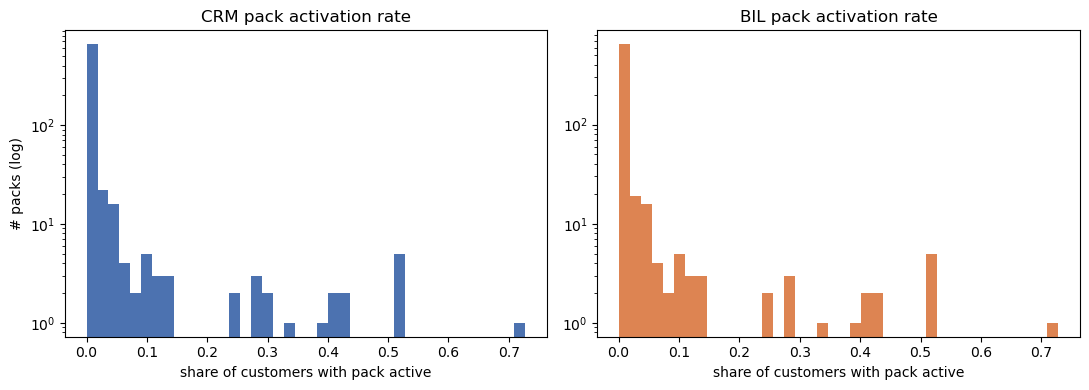

CRM packs active in <0.1% of rows: 16 / 730
BIL packs active in <0.1% of rows: 10 / 717


In [21]:
crm_rate = train[crm_packs].mean().sort_values(ascending=False)
bil_rate = train[bil_packs].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(crm_rate, bins=40, color='#4C72B0')
axes[0].set_title('CRM pack activation rate')
axes[0].set_xlabel('share of customers with pack active')
axes[0].set_ylabel('# packs (log)')
axes[0].set_yscale('log')
axes[1].hist(bil_rate, bins=40, color='#DD8452')
axes[1].set_title('BIL pack activation rate')
axes[1].set_xlabel('share of customers with pack active')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

print('CRM packs active in <0.1% of rows:', int((crm_rate < 0.001).sum()), '/', len(crm_rate))
print('BIL packs active in <0.1% of rows:', int((bil_rate < 0.001).sum()), '/', len(bil_rate))

save(pd.concat([
    crm_rate.rename('activation_rate').rename_axis('pack').reset_index().assign(system='CRM'),
    bil_rate.rename('activation_rate').rename_axis('pack').reset_index().assign(system='BIL'),
]), 'pack_activation_rates.csv');

**ADDED (§5) — the paired prevalence table.**

The previous version printed the CRM top-10 and the BIL top-10 as two separate lists and moved
on. Side by side they agree to four decimal places, pair by pair — the first evidence of a near
one-to-one channel structure between the two systems, which §6 confirms with association
statistics and §8b with a controlled contrast.

Caveat stated up front so the table is not over-read: matching prevalences in the **tail** prove
nothing, because hundreds of columns bunch between 0.001 and 0.0014 and would line up by
construction. The evidence is in the head, where the values are distinct.

In [22]:
k = 15
paired = pd.DataFrame({
    'rank': np.arange(1, k + 1),
    'crm_pack': crm_rate.index[:k], 'crm_rate': crm_rate.values[:k],
    'bil_pack': bil_rate.index[:k], 'bil_rate': bil_rate.values[:k],
})
paired['abs_diff'] = (paired['crm_rate'] - paired['bil_rate']).abs()
display(paired.round(6))
print(f'mean |difference| over the top {k} ranks: {paired["abs_diff"].mean():.6f}')
save(paired.round(8), 'paired_top_prevalence.csv');

,rank,crm_pack,crm_rate,bil_pack,bil_rate,abs_diff
0,1,CRM_1537_PACK,0.727409,BIL_3748_PACK,0.727542,0.000133
1,2,CRM_1542_PACK,0.520918,BIL_3933_PACK,0.520897,0.000021
2,3,CRM_1533_PACK,0.520908,BIL_3934_PACK,0.520844,0.000064
3,4,CRM_1529_PACK,0.520033,BIL_3921_PACK,0.520017,0.000016
4,5,CRM_1541_PACK,0.519009,BIL_3927_PACK,0.519057,0.000048
5,6,CRM_1532_PACK,0.514623,BIL_3922_PACK,0.514426,0.000197
6,7,CRM_2076_PACK,0.428463,BIL_3749_PACK,0.428202,0.000261
7,8,CRM_2077_PACK,0.423219,BIL_3750_PACK,0.422792,0.000427
8,9,CRM_2087_PACK,0.417414,BIL_3745_PACK,0.417116,0.000299
9,10,CRM_2088_PACK,0.402098,BIL_3744_PACK,0.401751,0.000347


mean |difference| over the top 15 ranks: 0.002771


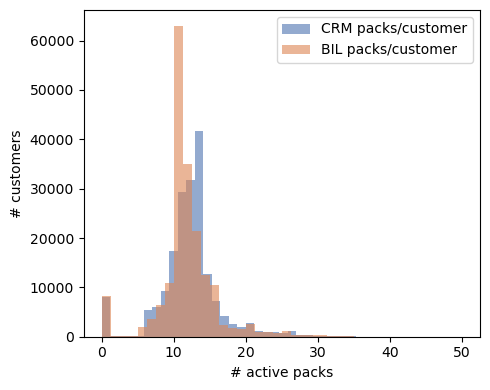

{'count': 187442.0, 'mean': 12.28, 'std': 4.36, 'min': 0.0, '25%': 11.0, '50%': 12.0, '75%': 14.0, 'max': 47.0}
{'count': 187442.0, 'mean': 11.68, 'std': 4.07, 'min': 0.0, '25%': 10.0, '50%': 11.0, '75%': 13.0, 'max': 50.0}

Correlation between #CRM packs and #BIL packs per customer: 0.932


In [23]:
crm_count = train[crm_packs].sum(axis=1)
bil_count = train[bil_packs].sum(axis=1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(crm_count, bins=40, alpha=0.6, label='CRM packs/customer', color='#4C72B0')
ax.hist(bil_count, bins=40, alpha=0.6, label='BIL packs/customer', color='#DD8452')
ax.set_xlabel('# active packs')
ax.set_ylabel('# customers')
ax.legend()
plt.tight_layout()
plt.show()

print(crm_count.describe().round(2).to_dict())
print(bil_count.describe().round(2).to_dict())
print(f'\nCorrelation between #CRM packs and #BIL packs per customer: '
      f'{crm_count.corr(bil_count):.3f}')

**ADDED (§5) — the count *difference* distribution, and zero-pack customers.**

A correlation of 0.93 between the two counts is suggestive but scale-free. The distribution of
`#CRM - #BIL` is sharper: it says whether the mapping *preserves* the number of items or
systematically expands or contracts it. Concentration at 0 or 1 is consistent with a near
one-to-one pack-level correspondence; a broad spread is not.

Zero-pack customers are isolated separately: if a customer with no commercial pack still
receives billing items, those items cannot come from any pack — direct evidence that part of the
billing configuration is driven by the categorical/status columns instead. That matters for
§3c and for the labels §6 finds unexplainable.

In [24]:
diff = crm_count - bil_count
print('#CRM packs - #BIL packs :', diff.describe().round(3).to_dict())
print('distribution (top 10)   :', diff.value_counts().sort_index().head(10).to_dict())
print(f'rows where the two counts are EQUAL: {(diff == 0).mean():.2%}')
print(f'rows where |difference| <= 1       : {(diff.abs() <= 1).mean():.2%}')

z = (crm_count == 0).to_numpy()
n_zero = int(z.sum())
print(f'\ncustomers with ZERO CRM packs: {n_zero:,} ({z.mean():.3%})')
zero_billed = int((bil_count[z] > 0).sum()) if n_zero else 0
if n_zero:
    print(f'  their mean BIL pack count             : {bil_count[z].mean():.2f}')
    print(f'  how many still receive >=1 BIL pack   : {zero_billed:,}')
    print(f'  distinct BIL configurations among them: {pd.Series(bil_code[z]).nunique():,}')

save(pd.DataFrame({
    'crm_packs_per_customer': crm_count.describe(),
    'bil_packs_per_customer': bil_count.describe(),
    'crm_minus_bil_packs': diff.describe(),
}).assign(
    crm_bil_pack_count_corr=round(float(crm_count.corr(bil_count)), 6),
    pct_rows_counts_equal=round(float((diff == 0).mean()), 6),
    pct_rows_count_diff_le_1=round(float((diff.abs() <= 1).mean()), 6),
    n_customers_zero_crm_packs=n_zero,
    n_zero_pack_customers_still_billed=zero_billed,
), 'pack_count_stats.csv', index=True);

#CRM packs - #BIL packs : {'count': 187442.0, 'mean': 0.607, 'std': 1.575, 'min': -18.0, '25%': 0.0, '50%': 0.0, '75%': 2.0, 'max': 24.0}
distribution (top 10)   : {-18: 4, -17: 1, -16: 5, -15: 7, -14: 8, -13: 16, -12: 27, -11: 41, -10: 68, -9: 118}
rows where the two counts are EQUAL: 63.48%
rows where |difference| <= 1       : 66.49%

customers with ZERO CRM packs: 1 (0.001%)
  their mean BIL pack count             : 1.00
  how many still receive >=1 BIL pack   : 1
  distinct BIL configurations among them: 1


## 5b. Pack-count outliers (IQR) — flagged, never removed

`crm_count`/`bil_count` are right-skewed and long-tailed, so Tukey's IQR fences are used instead
of z-scores — z-scores assume rough symmetry and would over-flag the tail of a skewed
distribution using a mean/std that the tail itself distorts.

**Flag, don't remove or cap.** A customer with an unusual pack count isn't a measurement error —
they're a real row that still needs a correct BIL prediction in test. Capping or dropping them
strips exactly the hard cases out of training with no evidence anything is wrong.

**ADDED (§5b).** An IQR fence on a bounded count with median 12 flags ~13% of rows, which is
simply the tail of a skewed count, not an anomaly. The fence alone carries no information, so
the bands below are given a measured consequence — ambiguity rate, billing complexity,
configuration diversity — which converts an arbitrary threshold into a finding about *who* the
hard customers are.

In [25]:
crm_is_outlier, crm_lo, crm_hi = flag_count_outliers(crm_count)
bil_is_outlier, bil_lo, bil_hi = flag_count_outliers(bil_count)
outlier_mask = crm_is_outlier | bil_is_outlier

print(f'CRM pack-count IQR fences: [{crm_lo:.1f}, {crm_hi:.1f}] -> {int(crm_is_outlier.sum()):,} flagged')
print(f'BIL pack-count IQR fences: [{bil_lo:.1f}, {bil_hi:.1f}] -> {int(bil_is_outlier.sum()):,} flagged')
print(f'Union: {int(outlier_mask.sum()):,} / {len(train):,} rows ({outlier_mask.mean():.2%})')

pack_count_outliers = pd.DataFrame({
    'MSISDN': train.loc[outlier_mask, 'MSISDN'],
    'n_crm_packs': crm_count[outlier_mask],
    'n_bil_packs': bil_count[outlier_mask],
    'crm_outlier': crm_is_outlier[outlier_mask],
    'bil_outlier': bil_is_outlier[outlier_mask],
})
display(pack_count_outliers.head())
save(pack_count_outliers, 'pack_count_outliers.csv');

CRM pack-count IQR fences: [6.5, 18.5] -> 21,673 flagged
BIL pack-count IQR fences: [5.5, 17.5] -> 19,928 flagged
Union: 24,253 / 187,442 rows (12.94%)


,MSISDN,n_crm_packs,n_bil_packs,crm_outlier,bil_outlier
3,a543952f2405c440fc40f85e8adfdfd6,22,14,True,False
21,3bd71759181041e39304827d67870716,24,16,True,False
36,b447a2ae3036f1f4d8a45077a8c2264a,15,26,False,True
46,b07244a41b129847a8ef6265f531685d,17,18,False,True
100,da98d61522e313f8339c88e8e19abeb3,31,17,True,False


In [26]:
is_amb = (nuniq > 1).reindex(pairs['crm']).to_numpy()
bucket = pd.cut(crm_count, [-1, 6, 12, 18, np.inf], labels=['0-6', '7-12', '13-18', '19+'])

ev = pd.DataFrame({'bucket': bucket, 'n_bil': bil_count.to_numpy(), 'ambiguous': is_amb,
                   'cfg': crm_code, 'iqr_flagged': outlier_mask.to_numpy()})
band = ev.groupby('bucket', observed=True).agg(
    rows=('n_bil', 'size'),
    share_of_rows=('n_bil', lambda s: len(s) / len(ev)),
    mean_bil_packs=('n_bil', 'mean'),
    ambiguity_rate=('ambiguous', 'mean'),
    distinct_configs=('cfg', 'nunique'),
    iqr_flagged_share=('iqr_flagged', 'mean'),
).round(4)
display(band)
print('Read: if ambiguity_rate and distinct_configs rise sharply with pack count, the')
print('      high-count band is a genuinely harder population — worth monitoring separately')
print('      in Sprint 2 rather than deleting.')
save(band.reset_index(), 'pack_count_bands.csv');

,rows,share_of_rows,mean_bil_packs,ambiguity_rate,distinct_configs,iqr_flagged_share
bucket,,,,,,
0-6,10380,0.0554,2.0239,0.9177,513,1.0000
7-12,97323,0.5192,10.4270,0.4354,17190,0.0019
13-18,68446,0.3652,13.3309,0.0949,38498,0.0350
19+,11293,0.0602,21.3018,0.0003,11233,1.0000


Read: if ambiguity_rate and distinct_configs rise sharply with pack count, the
      high-count band is a genuinely harder population — worth monitoring separately
      in Sprint 2 rather than deleting.


## 5c. Label imbalance audit

Bucketing each column's activation rate from ultra-rare to dense. This matters specifically
*because* the metric is EMR: a classifier predicting all-zero for a rare BIL pack still scores
well on per-label accuracy, but under EMR that one wrong bit fails the entire row.

**ADDED (§5c).** The tier counts describe the *columns*. The quantity that actually bounds EMR
is the share of **rows** containing at least one rare positive — exactly the fraction an
all-zero-on-the-tail predictor fails, however good it is elsewhere.

In [27]:
crm_imbalance = label_imbalance_report(train[crm_cols].mean())
bil_imbalance = label_imbalance_report(train[bil_cols].mean())
print('CRM columns:')
display(crm_imbalance)
print('\nBIL columns (the actual prediction targets):')
display(bil_imbalance)

save(pd.concat([crm_imbalance.assign(system='CRM'), bil_imbalance.assign(system='BIL')]),
     'label_imbalance.csv');

CRM columns:


,imbalance_tier,n_columns
0,ultra_rare(<0.1%),16
1,rare(0.1-1%),613
2,uncommon(1-10%),82
3,common(10-50%),25
4,dense(>=50%),9



BIL columns (the actual prediction targets):


,imbalance_tier,n_columns
0,ultra_rare(<0.1%),10
1,rare(0.1-1%),607
2,uncommon(1-10%),82
3,common(10-50%),23
4,dense(>=50%),9


In [28]:
rows_ = []
for thr, name in [(0.001, 'ultra-rare (<0.1%)'), (0.01, 'rare (<1%)'),
                  (0.10, 'uncommon (<10%)')]:
    idx = np.flatnonzero(bil_rate_all.to_numpy() < thr)
    has = Yc[:, idx].sum(1) > 0
    print(f'{name:<22} {len(idx):>3} BIL columns | rows holding >=1 such positive: '
          f'{has.mean():>7.2%} -> EMR ceiling if all predicted 0: {1 - has.mean():.4f}')
    rows_.append({'tier': name, 'threshold': thr, 'n_bil_columns': int(len(idx)),
                  'pct_rows_with_at_least_one_positive': round(float(has.mean()), 6),
                  'emr_ceiling_if_predicted_all_zero': round(float(1 - has.mean()), 6)})
save(pd.DataFrame(rows_), 'rare_label_row_coverage.csv');

ultra-rare (<0.1%)      10 BIL columns | rows holding >=1 such positive:   0.92% -> EMR ceiling if all predicted 0: 0.9908
rare (<1%)             617 BIL columns | rows holding >=1 such positive:  38.35% -> EMR ceiling if all predicted 0: 0.6165
uncommon (<10%)        699 BIL columns | rows holding >=1 such positive:  93.99% -> EMR ceiling if all predicted 0: 0.0601


## 6. Association structure between CRM and BILLING

**REWRITTEN (§6).** Two material changes.

1. **No subsample.** The previous version computed every correlation on 30,000 rows "to keep the
   pairwise computation fast". With `cooc` the full association matrix over all 187,442 rows is
   a chunked matmul, so there is no reason to accept sampling noise — and it was not harmless: a
   column with prevalence 0.001 has about 30 positives in 30k rows, so its estimate is noise,
   and those are precisely the columns the section labels "hard".

2. **Directional statistics.** Pearson/phi is *symmetric*. The brief's central structural claim —
   many CRM configurations mapping to one billing configuration — is directional, and a
   symmetric statistic cannot express it. `P(BIL_k | CRM_j)` identifies a **trigger**;
   `P(CRM_j | BIL_k)` identifies a **necessary condition**. Both are reported.

Jaccard replaces phi for the pairing question: it is the standard similarity for
presence/absence data and is not distorted by prevalence the way phi is.

In [29]:
Xp = train[crm_packs].to_numpy(np.uint8)
Yp = train[bil_packs].to_numpy(np.uint8)

n11 = cooc(Xp, Yp)                                    # full data, chunked
nx_ = Xp.sum(0).astype(float)
ny_ = Yp.sum(0).astype(float)

conf_fwd = n11 / np.maximum(nx_[:, None], 1)          # P(BIL_k | CRM_j)  -- trigger
conf_rev = n11 / np.maximum(ny_[None, :], 1)          # P(CRM_j | BIL_k)  -- necessary condition
jac = n11 / np.maximum(nx_[:, None] + ny_[None, :] - n11, 1)

# within-family co-occurrence, computed ONCE here and reused by 6b and 7c (the previous
# version recomputed these in separate cells).
Cxx = cooc(Xp, Xp)
Jxx = Cxx / np.maximum(nx_[:, None] + nx_[None, :] - Cxx, 1)
np.fill_diagonal(Jxx, 0.0)
Cyy = cooc(Yp, Yp)
Jyy = Cyy / np.maximum(ny_[:, None] + ny_[None, :] - Cyy, 1)
np.fill_diagonal(Jyy, 0.0)

print('association matrices:', n11.shape, f'(computed on all {len(Xp):,} rows)')
print('within-family matrices:', Jxx.shape, Jyy.shape)

association matrices: (730, 717) (computed on all 187,442 rows)
within-family matrices: (730, 730) (717, 717)


**ADDED (§6) — read the one-to-one channels out loud.**

The previous version produced this table under the heading "strongest single-feature
predictors" and left it uncommented. It is the central structural observation of the dataset:
several mutually-bundled CRM packs each drive a *different* billing item, at ~0.99 confidence in
**both** directions. Bundled together is not the same as interchangeable — a distinction that
matters enormously for any deduplication decision.

In [30]:
bidx = np.arange(len(bil_packs))
best = jac.argmax(0)
channels = pd.DataFrame({
    'bil_pack': bil_packs,
    'best_crm_pack': [crm_packs[j] for j in best],
    'jaccard': jac.max(0),
    'conf_fwd_P_bil_given_crm': conf_fwd[best, bidx],
    'conf_rev_P_crm_given_bil': conf_rev[best, bidx],
    'bil_prevalence': ny_ / len(Yp),
}).round(6)

print('Top 20 CRM -> BIL channels (near one-to-one in both directions):')
display(channels.sort_values('jaccard', ascending=False).head(20))
print('\nTop 20 HARDEST BIL packs (weakest best partner):')
display(channels.sort_values('jaccard').head(20))
save(channels.sort_values('jaccard', ascending=False), 'crm_bil_channels.csv');

Top 20 CRM -> BIL channels (near one-to-one in both directions):


,bil_pack,best_crm_pack,jaccard,conf_fwd_P_bil_given_crm,conf_rev_P_crm_given_bil,bil_prevalence
9,BIL_3748_PACK,CRM_1537_PACK,0.996333,0.998254,0.998071,0.727542
85,BIL_3934_PACK,CRM_1533_PACK,0.995973,0.997921,0.998044,0.520844
84,BIL_3933_PACK,CRM_1533_PACK,0.995891,0.997931,0.997952,0.520897
78,BIL_3927_PACK,CRM_1541_PACK,0.995702,0.997893,0.997800,0.519057
72,BIL_3921_PACK,CRM_1529_PACK,0.995506,0.997733,0.997763,0.520017
73,BIL_3922_PACK,CRM_1532_PACK,0.995397,0.997502,0.997884,0.514426
7,BIL_3745_PACK,CRM_2087_PACK,0.994238,0.996754,0.997468,0.417116
6,BIL_3744_PACK,CRM_2088_PACK,0.994163,0.996643,0.997503,0.401751
86,BIL_3935_PACK,CRM_1538_PACK,0.994121,0.996867,0.997237,0.388083
10,BIL_3749_PACK,CRM_2076_PACK,0.994052,0.996713,0.997321,0.428202



Top 20 HARDEST BIL packs (weakest best partner):


,bil_pack,best_crm_pack,jaccard,conf_fwd_P_bil_given_crm,conf_rev_P_crm_given_bil,bil_prevalence
617,BIL_4355_PACK,CRM_2297_PACK,0.017199,0.033175,0.034483,0.001083
622,BIL_4360_PACK,CRM_1962_PACK,0.017677,0.031963,0.038043,0.000982
676,BIL_4431_PACK,CRM_2370_PACK,0.017857,0.034934,0.035242,0.001211
237,BIL_3856_PACK,CRM_2371_PACK,0.017949,0.034314,0.036269,0.001030
565,BIL_4342_PACK,CRM_2183_PACK,0.018088,0.034653,0.036458,0.001024
534,BIL_4294_PACK,CRM_2065_PACK,0.018100,0.034483,0.036697,0.001163
397,BIL_3818_PACK,CRM_1909_PACK,0.018182,0.034483,0.037037,0.001152
701,BIL_4459_PACK,CRM_1717_PACK,0.018182,0.034783,0.036697,0.001163
434,BIL_3906_PACK,CRM_1782_PACK,0.018229,0.035354,0.036269,0.001030
276,BIL_4030_PACK,CRM_1890_PACK,0.018307,0.033755,0.038462,0.001110


best Jaccard per BIL pack, quantiles (0,.05,.25,.5,.75,.95,1): [0.0172 0.0194 0.0234 0.0994 0.5377 0.9539 0.9963]
  t=0.99 | best Jaccard >= t:   16 | has trigger P(BIL|CRM) >= t:   32 | has necessary cond. P(CRM|BIL) >= t:   33
  t=0.95 | best Jaccard >= t:   41 | has trigger P(BIL|CRM) >= t:   69 | has necessary cond. P(CRM|BIL) >= t:  103
  t=0.90 | best Jaccard >= t:   63 | has trigger P(BIL|CRM) >= t:  106 | has necessary cond. P(CRM|BIL) >= t:  154
  t=0.50 | best Jaccard >= t:  195 | has trigger P(BIL|CRM) >= t:  238 | has necessary cond. P(CRM|BIL) >= t:  717
  t=0.30 | best Jaccard >= t:  249 | has trigger P(BIL|CRM) >= t:  314 | has necessary cond. P(CRM|BIL) >= t:  717


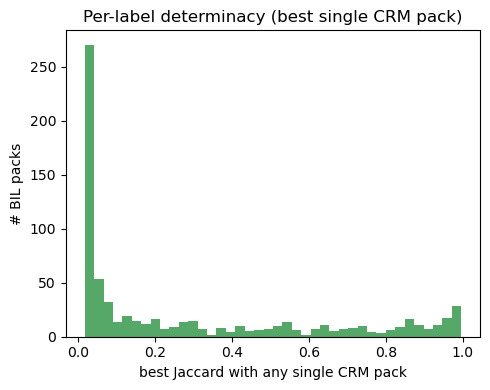

In [31]:
print('best Jaccard per BIL pack, quantiles (0,.05,.25,.5,.75,.95,1):',
      np.round(np.quantile(jac.max(0), [0, .05, .25, .5, .75, .95, 1]), 4))

thr_rows = []
for t in [0.99, 0.95, 0.90, 0.50, 0.30]:
    a = int((jac.max(0) >= t).sum())
    b = int((conf_fwd.max(0) >= t).sum())
    c = int((conf_rev.max(0) >= t).sum())
    print(f'  t={t:.2f} | best Jaccard >= t: {a:>4} | has trigger P(BIL|CRM) >= t: {b:>4} '
          f'| has necessary cond. P(CRM|BIL) >= t: {c:>4}')
    thr_rows.append({'threshold': t, 'n_bil_with_jaccard_ge_t': a,
                     'n_bil_with_trigger_ge_t': b, 'n_bil_with_necessary_cond_ge_t': c})
save(pd.DataFrame(thr_rows), 'association_thresholds.csv')

plt.figure(figsize=(5, 4))
plt.hist(jac.max(0), bins=40, color='#55A868')
plt.xlabel('best Jaccard with any single CRM pack')
plt.ylabel('# BIL packs')
plt.title('Per-label determinacy (best single CRM pack)')
plt.tight_layout()
plt.show()

save(pd.DataFrame({'bil_pack': bil_packs,
                   'best_jaccard': jac.max(0).round(6),
                   'best_conf_fwd': conf_fwd.max(0).round(6),
                   'best_conf_rev': conf_rev.max(0).round(6)}),
     'bil_predictability.csv');

## 6b. Exact duplicate columns

**ADDED (§6b).** Any deduplication based on a correlation *threshold* silently assumes 0.99 is
close enough to 1.00. For targets under EMR it is not: two columns correlated at 0.996 still
disagree on hundreds of rows, and each disagreement fails a whole row.

Column hashing answers the question exactly and without a threshold: which columns are
*literally identical* across all 187,442 rows. Only those are safe to collapse — and only on the
feature side, never among the 731 targets, all of which must be emitted.

In [32]:
dup_rows = []
for name, cols, M in [('CRM', crm_cols, Xc), ('BIL', bil_cols, Yc)]:
    d = defaultdict(list)
    for c, kk in zip(cols, col_keys(M)):
        d[kk].append(c)
    dup = [v for v in d.values() if len(v) > 1]
    print(f'{name}: {len(dup)} groups of EXACTLY identical columns')
    for g_ in dup:
        print('   ', g_)
        dup_rows.append({'system': name, 'n_columns': len(g_), 'columns': ';'.join(g_)})
save(pd.DataFrame(dup_rows) if dup_rows else pd.DataFrame(
    [{'system': None, 'n_columns': 0, 'columns': None}]), 'exact_duplicate_columns.csv')

print('\nTop near-duplicate BIL pairs by Jaccard, with their TRUE row disagreement:')
iu = np.triu_indices(len(bil_packs), k=1)
ordr = np.argsort(-Jyy[iu])[:15]
near_rows = []
for t in ordr:
    a, b = int(iu[0][t]), int(iu[1][t])
    disagree = float((Yp[:, a] != Yp[:, b]).mean())
    print(f'  {bil_packs[a]:>16} / {bil_packs[b]:>16}  jaccard={Jyy[a, b]:.4f}  '
          f'rows differing={disagree:.4%}')
    near_rows.append({'col_a': bil_packs[a], 'col_b': bil_packs[b],
                      'jaccard': round(float(Jyy[a, b]), 6),
                      'pct_rows_differing': round(disagree, 8)})
save(pd.DataFrame(near_rows), 'near_duplicate_bil_pairs.csv')
print('\n-> collapsing any of these would hard-cap EMR at roughly the product of')
print('   (1 - pct_rows_differing) across the collapsed pairs. Keep all 731 targets.')

# ADDED (6b): the CRM counterpart. Bundled-together is not interchangeable — each member of a
# near-duplicate CRM pair is shown with the BIL pack IT drives, which is the direct evidence.
print('\nTop near-duplicate CRM pairs, each member with the BIL pack it drives:')
iu_x = np.triu_indices(len(crm_packs), k=1)
ordr_x = np.argsort(-Jxx[iu_x])[:15]
crm_near = []
for t in ordr_x:
    a, b = int(iu_x[0][t]), int(iu_x[1][t])
    ba, bb = int(jac[a].argmax()), int(jac[b].argmax())
    print(f'  {crm_packs[a]:>16} / {crm_packs[b]:>16}  jaccard={Jxx[a, b]:.4f}  '
          f'| drives {bil_packs[ba]:>16} vs {bil_packs[bb]:>16}  '
          f"{'SAME' if ba == bb else 'DIFFERENT'}")
    crm_near.append({'col_a': crm_packs[a], 'col_b': crm_packs[b],
                     'jaccard': round(float(Jxx[a, b]), 6),
                     'pct_rows_differing': round(float((Xp[:, a] != Xp[:, b]).mean()), 8),
                     'best_bil_for_a': bil_packs[ba], 'best_bil_for_b': bil_packs[bb],
                     'drives_same_bil_pack': bool(ba == bb)})
save(pd.DataFrame(crm_near), 'near_duplicate_crm_pairs.csv')
print('\n-> where drives_same_bil_pack is False, the two CRM packs are bundled but NOT')
print('   redundant: collapsing them would destroy a distinct trigger.')

CRM: 1 groups of EXACTLY identical columns
    ['CRM_2396_PACK', 'CRM_2398_PACK']
BIL: 0 groups of EXACTLY identical columns

Top near-duplicate BIL pairs by Jaccard, with their TRUE row disagreement:
     BIL_3933_PACK /    BIL_3934_PACK  jaccard=0.9959  rows differing=0.2145%
     BIL_3921_PACK /    BIL_3934_PACK  jaccard=0.9940  rows differing=0.3132%
     BIL_3921_PACK /    BIL_3933_PACK  jaccard=0.9939  rows differing=0.3164%
     BIL_3927_PACK /    BIL_3934_PACK  jaccard=0.9922  rows differing=0.4071%
     BIL_3927_PACK /    BIL_3933_PACK  jaccard=0.9922  rows differing=0.4081%
     BIL_3921_PACK /    BIL_3927_PACK  jaccard=0.9907  rows differing=0.4866%
     BIL_3922_PACK /    BIL_3934_PACK  jaccard=0.9833  rows differing=0.8712%
     BIL_3922_PACK /    BIL_3933_PACK  jaccard=0.9833  rows differing=0.8733%
     BIL_3921_PACK /    BIL_3922_PACK  jaccard=0.9813  rows differing=0.9763%
     BIL_3922_PACK /    BIL_3927_PACK  jaccard=0.9795  rows differing=1.0681%
     BIL_3749_PACK 

## 7. Structure discovery

**REPLACED (§7).** The previous version ran `TruncatedSVD(20)` + `MiniBatchKMeans(8)` on the
customer x pack matrix and reported "68.9% of variance explained" with an 8-cluster profile.
Three problems, addressed in 7a–7d:

* variance is the wrong objective for sparse binary data (7a);
* `TruncatedSVD` does not centre, so the leading component tracks row norm — i.e. **pack
  count** — which is why the old clusters ordered by pack count (7a);
* clustering *customers* was never tied to a decision, and `k = 8` had no validity measure (7d).

The structure in this dataset lives in the **packs** and in the **CRM-to-BILLING relation**, not
in the customers, so 7b and 7c cluster those instead.

### 7a. Why PCA / truncated SVD is rejected here

For a Bernoulli column, variance is `p(1-p)`. With a median prevalence around 0.0014, a dense
column at `p = 0.52` carries roughly 180x the variance of a typical rare one. PCA maximises
explained variance, so its leading components are determined almost entirely by the handful of
dense packs — and the rare packs, which are exactly where the modelling difficulty lies, are
invisible in them.

Running the standard tool and rejecting it with measurements is more informative than omitting
it.

In [33]:
p = Xp.mean(0)
v = p * (1 - p)
o = np.sort(v)[::-1]
conc = []
print('Variance concentration across the CRM pack columns:')
for k_ in [5, 10, 20, 50, 100]:
    share = float(o[:k_].sum() / v.sum())
    print(f'  top {k_:>3} columns hold {share:6.1%} of total variance')
    conc.append({'top_k_columns': k_, 'share_of_total_variance': round(share, 6)})
n90 = int((np.cumsum(o) / v.sum() < 0.90).sum()) + 1
print(f'  columns needed for 90% of variance: {n90} of {len(o)}')

from sklearn.decomposition import PCA
sub_idx = RNG.choice(len(Xp), min(30000, len(Xp)), replace=False)
sub = Xp[sub_idx].astype(np.float32)
pca = PCA(n_components=5, random_state=0).fit(sub)
Z = pca.transform(sub)
npacks = sub.sum(1)
print(f'\nexplained variance of 5 PCs: {pca.explained_variance_ratio_.sum():.1%}')
pc_rows = []
for i in range(3):
    c_ = float(np.corrcoef(Z[:, i], npacks)[0, 1])
    print(f'  corr(PC{i+1}, #packs per customer) = {c_:+.3f}')
    pc_rows.append({'component': f'PC{i+1}', 'corr_with_pack_count': round(c_, 6)})
# FIXED (7a): sklearn's PCA CENTRES the data; the previous notebook used TruncatedSVD, which
# does not. Testing a claim about the uncentred estimator with the centred one is the wrong
# comparison, so both are reported.
from sklearn.decomposition import TruncatedSVD
svd_u = TruncatedSVD(n_components=5, random_state=0).fit(sub)
Zu = svd_u.transform(sub)
print('\nuncentred TruncatedSVD (what the previous version used):')
for i in range(3):
    cu = float(np.corrcoef(Zu[:, i], npacks)[0, 1])
    print(f'  corr(SV{i+1}, #packs per customer) = {cu:+.3f}')
    pc_rows.append({'component': f'SV{i+1} (uncentred)', 'corr_with_pack_count': round(cu, 6)})

print('\nCONCLUSION: the variance argument stands on its own — a handful of dense columns')
print('            carry most of the variance, so the rare packs that drive the modelling')
print('            difficulty are invisible to any variance-maximising projection. Whether')
print('            component 1 is literally a pack-count proxy depends on centring: compare')
print('            the two blocks above. Either way, linear dimensionality reduction is')
print('            inappropriate for a sparse binary, set-valued feature space; the')
print('            appropriate decomposition is Boolean (see 8b).')

save(pd.DataFrame(conc).assign(n_columns_for_90pct_variance=n90,
                               explained_variance_5pc=round(float(pca.explained_variance_ratio_.sum()), 6)),
     'pca_variance_concentration.csv')
save(pd.DataFrame(pc_rows), 'pca_component_vs_pack_count.csv');

Variance concentration across the CRM pack columns:
  top   5 columns hold  14.4% of total variance
  top  10 columns hold  28.4% of total variance
  top  20 columns hold  50.7% of total variance
  top  50 columns hold  73.7% of total variance
  top 100 columns hold  84.9% of total variance
  columns needed for 90% of variance: 166 of 730

explained variance of 5 PCs: 51.0%
  corr(PC1, #packs per customer) = +0.344
  corr(PC2, #packs per customer) = +0.309
  corr(PC3, #packs per customer) = +0.072

uncentred TruncatedSVD (what the previous version used):
  corr(SV1, #packs per customer) = +0.561
  corr(SV2, #packs per customer) = -0.237
  corr(SV3, #packs per customer) = +0.085

CONCLUSION: the variance argument stands on its own — a handful of dense columns
            carry most of the variance, so the rare packs that drive the modelling
            difficulty are invisible to any variance-maximising projection. Whether
            component 1 is literally a pack-count proxy depends 

### 7b. Co-clustering the CRM x BILLING association

**ADDED (§7b).** This clusters the two families *jointly*, so blocks of (commercial offer,
billing component) pairs emerge — it recovers catalogue structure rather than customer segments.
The matrix is small, so this is cheap.

The validity measure is stated in advance: the share of **strong** pairs (Jaccard > 0.5) falling
inside a block. If a modest number of blocks captures most of them, the catalogue has real block
structure; if not, that is also a reportable result.

In [34]:
from sklearn.cluster import SpectralCoclustering

keep_r, keep_c = jac.sum(1) > 0, jac.sum(0) > 0
Jk = jac[np.ix_(keep_r, keep_c)]
print(f'co-clustering a {Jk.shape[0]} x {Jk.shape[1]} Jaccard matrix')

strong = Jk > 0.5
co_rows = []
for k_ in [6, 10, 15, 25, 40]:
    try:
        mdl = SpectralCoclustering(n_clusters=k_, random_state=0, svd_method='arpack').fit(Jk)
    except Exception as e:
        print(f'k={k_}: {type(e).__name__}')
        continue
    inside = np.zeros_like(Jk, bool)
    for b in range(k_):
        r, c = mdl.get_indices(b)
        if len(r) and len(c):
            inside[np.ix_(r, c)] = True
    co_rows.append({'k': k_,
                    'strong_pairs_inside': int((strong & inside).sum()),
                    'strong_pairs_total': int(strong.sum()),
                    'captured': round(float((strong & inside).sum() / max(strong.sum(), 1)), 4),
                    'mean_jaccard_inside': round(float(Jk[inside].mean()), 6) if inside.any() else np.nan,
                    'mean_jaccard_outside': round(float(Jk[~inside].mean()), 6)})
co_df = pd.DataFrame(co_rows)
display(co_df)
save(co_df, 'coclustering_quality.csv');

co-clustering a 728 x 717 Jaccard matrix


,k,strong_pairs_inside,strong_pairs_total,captured,mean_jaccard_inside,mean_jaccard_outside
0,6,386,390,0.9897,0.007386,0.003084
1,10,388,390,0.9949,0.007441,0.003152
2,15,382,390,0.9795,0.007880,0.003451
3,25,366,390,0.9385,0.007816,0.003712
4,40,334,390,0.8564,0.008330,0.004041


### 7c. Bundles as communities in the pack co-occurrence graph

**ADDED (§7c).** For "which packs travel together" this beats hierarchical clustering on a dense
correlation matrix: it works on a sparse weighted graph, uses a similarity appropriate to
presence/absence data, **chooses its own number of communities**, and comes with modularity as a
built-in validity measure. Modularity above ~0.3 indicates genuine community structure; a low
value is itself a finding ("packs do not form clean bundles").

In [35]:
import networkx as nx

# Jxx computed once in 6 and reused here.
comm_rows = []
for thr in [0.2, 0.3, 0.5]:
    W = np.where(Jxx >= thr, Jxx, 0.0)
    G = nx.from_numpy_array(W)
    G.remove_nodes_from(list(nx.isolates(G)))
    if G.number_of_nodes() == 0:
        print(f'thr={thr}: graph empty')
        continue
    comm = nx.community.louvain_communities(G, seed=0)
    q = nx.community.modularity(G, comm)
    print(f'thr={thr}  nodes={G.number_of_nodes():>4}  edges={G.number_of_edges():>6}  '
          f'communities={len(comm):>3}  modularity={q:.3f}  '
          f'sizes={sorted(map(len, comm), reverse=True)[:8]}')
    comm_rows.append({'jaccard_threshold': thr, 'n_nodes': G.number_of_nodes(),
                      'n_edges': G.number_of_edges(), 'n_communities': len(comm),
                      'modularity': round(float(q), 6)})
save(pd.DataFrame(comm_rows), 'pack_community_quality.csv')

W = np.where(Jxx >= 0.3, Jxx, 0.0)
G = nx.from_numpy_array(W)
G.remove_nodes_from(list(nx.isolates(G)))
comm = sorted(nx.community.louvain_communities(G, seed=0), key=len, reverse=True)
print('\nlargest bundles (threshold 0.3):')
memb = []
for ci, c in enumerate(comm):
    for i in sorted(c):
        memb.append({'community': ci, 'crm_pack': crm_packs[i],
                     'activation_rate': round(float(p[i]), 8)})
for c in comm[:5]:
    print('  ', [crm_packs[i] for i in sorted(c)][:12])
save(pd.DataFrame(memb), 'pack_communities.csv');

thr=0.2  nodes= 158  edges=   331  communities= 43  modularity=0.798  sizes=[17, 12, 11, 9, 7, 6, 6, 6]
thr=0.3  nodes= 116  edges=   200  communities= 31  modularity=0.826  sizes=[12, 11, 7, 7, 6, 6, 6, 5]
thr=0.5  nodes=  61  edges=   104  communities= 18  modularity=0.806  sizes=[9, 8, 5, 4, 4, 4, 4, 3]

largest bundles (threshold 0.3):
   ['CRM_1527_PACK', 'CRM_1529_PACK', 'CRM_1532_PACK', 'CRM_1533_PACK', 'CRM_1536_PACK', 'CRM_1537_PACK', 'CRM_1538_PACK', 'CRM_1539_PACK', 'CRM_1541_PACK', 'CRM_1542_PACK', 'CRM_1553_PACK', 'CRM_1594_PACK']
   ['CRM_2076_PACK', 'CRM_2077_PACK', 'CRM_2078_PACK', 'CRM_2079_PACK', 'CRM_2080_PACK', 'CRM_2081_PACK', 'CRM_2087_PACK', 'CRM_2088_PACK', 'CRM_2089_PACK', 'CRM_2091_PACK', 'CRM_2093_PACK']
   ['CRM_1519_PACK', 'CRM_1576_PACK', 'CRM_1577_PACK', 'CRM_1613_PACK', 'CRM_1641_PACK', 'CRM_1675_PACK', 'CRM_1689_PACK']
   ['CRM_1610_PACK', 'CRM_1611_PACK', 'CRM_1633_PACK', 'CRM_1741_PACK', 'CRM_1745_PACK', 'CRM_1754_PACK', 'CRM_1755_PACK']
   ['CRM_1528

### 7d. Customer clustering, done honestly

**CHANGED (§7d).** Three fixes:

* cluster **distinct configurations** rather than rows, so the 63.6% duplicates do not weight
  the result;
* use **Jaccard** distance rather than Euclidean distance on uncentred SVD components;
* report a **silhouette** per `k` instead of fixing `k = 8` with no validation.

A low silhouette across all `k` is a legitimate and useful conclusion: the configuration space is
a continuum, not a set of clusters — worth stating before anyone builds a segment-based model on
top of it.

The one genuinely informative statistic from the old cluster profile is kept: whether a segment
**preserves the pack count** from CRM to BILLING. Segments where the two means coincide are
consistent with a one-to-one pack mapping; segments that lose packs are where the mapping does
something else.

In [36]:
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

U = Xp[first_x.to_numpy()]                      # one row per distinct CRM configuration
print(f'{len(U):,} distinct configurations (vs {len(Xp):,} rows)')

s_idx = RNG.choice(len(U), min(3000, len(U)), replace=False)
S = U[s_idx].astype(bool)
D = squareform(pdist(S, metric='jaccard'))

sil_rows = []
for k_ in [3, 5, 8, 12, 20]:
    lab = AgglomerativeClustering(n_clusters=k_, metric='precomputed',
                                  linkage='average').fit_predict(D)
    sil = float(silhouette_score(D, lab, metric='precomputed'))
    print(f'  k={k_:>3}  silhouette (Jaccard) = {sil:+.3f}  sizes={np.bincount(lab)[:8]}')
    sil_rows.append({'k': k_, 'silhouette_jaccard': round(sil, 6),
                     'largest_cluster_share': round(float(np.bincount(lab).max() / len(lab)), 4)})

# FIXED (7d): the verdict is derived from the measured silhouette instead of asserted.
bs = max(sil_rows, key=lambda r: r['silhouette_jaccard'])
v = bs['silhouette_jaccard']
if v < 0.15:
    verdict = 'no meaningful cluster structure — a continuum, not segments'
elif v < 0.35:
    verdict = ('a COARSE split only — moderate separation at the best k, decaying as k grows, '
               'which indicates a few broad groups plus outliers rather than a clean '
               'segmentation that refines')
else:
    verdict = 'genuine cluster structure worth using'
print(f'\nbest k={bs["k"]} at silhouette {v:+.3f}; largest cluster holds '
      f'{bs["largest_cluster_share"]:.1%} of the sample')
print('->', verdict)
save(pd.DataFrame(sil_rows), 'customer_cluster_silhouette.csv');

67,434 distinct configurations (vs 187,442 rows)
  k=  3  silhouette (Jaccard) = +0.306  sizes=[  38  849 2113]
  k=  5  silhouette (Jaccard) = +0.304  sizes=[  36  849 2113    1    1]
  k=  8  silhouette (Jaccard) = +0.298  sizes=[  28  849    4    2    1 2113    2    1]
  k= 12  silhouette (Jaccard) = +0.291  sizes=[  21    3    3    2  848 2113    2    1]
  k= 20  silhouette (Jaccard) = +0.282  sizes=[  2   4   3   2   7 835   2   2]

best k=3 at silhouette +0.306; largest cluster holds 70.4% of the sample
-> a COARSE split only — moderate separation at the best k, decaying as k grows, which indicates a few broad groups plus outliers rather than a clean segmentation that refines


In [37]:
lab_full = AgglomerativeClustering(n_clusters=8, metric='precomputed',
                                   linkage='average').fit_predict(D)
prof = pd.DataFrame({'cluster': lab_full,
                     'n_crm_packs': S.sum(1),
                     'n_bil_packs': Yp[first_x.to_numpy()[s_idx]].sum(1)})
summ = prof.groupby('cluster').agg(size=('cluster', 'size'),
                                   avg_crm_packs=('n_crm_packs', 'mean'),
                                   avg_bil_packs=('n_bil_packs', 'mean')).round(3)
summ['count_preserved'] = (summ['avg_crm_packs'] - summ['avg_bil_packs']).abs() < 0.05
display(summ)
print('ADDED (7d): segments where the pack count is PRESERVED are consistent with a')
print('            one-to-one pack mapping; those that lose packs are where it is not.')
save(summ.reset_index(), 'customer_segments.csv');

,size,avg_crm_packs,avg_bil_packs,count_preserved
cluster,,,,
0,28,7.821,8.464,False
1,849,14.449,14.378,False
2,4,15.250,9.500,False
3,2,14.500,15.500,False
4,1,22.000,19.000,False
5,2113,15.513,14.404,False
6,2,13.000,8.000,False
7,1,22.000,22.000,True


ADDED (7d): segments where the pack count is PRESERVED are consistent with a
            one-to-one pack mapping; those that lose packs are where it is not.


## 8. Aggregation by billing configuration (long tail)

How much of the customer base is covered by a small number of common configurations? If a small
set covered most customers, Sprint 2 could partly frame this as "classify into a known bundle,
handle the long tail separately".

**CHANGED (§8).** The previous version posed this question and then repeated it in the summary
as a conditional, as if the answer were favourable. The output answers it, and the answer is
negative — so it is resolved here instead of being carried forward.

Top 15 most common BIL configurations:
 rank    share  n_active_labels
    1 0.043331                4
    2 0.014554               14
    3 0.014026               14
    4 0.009166               13
    5 0.007778               14
    6 0.007725               13
    7 0.007208                9
    8 0.006583               13
    9 0.006514               10
   10 0.006274               13
   11 0.004924               12
   12 0.004689               11
   13 0.004364               15
   14 0.003879               14
   15 0.003772               15


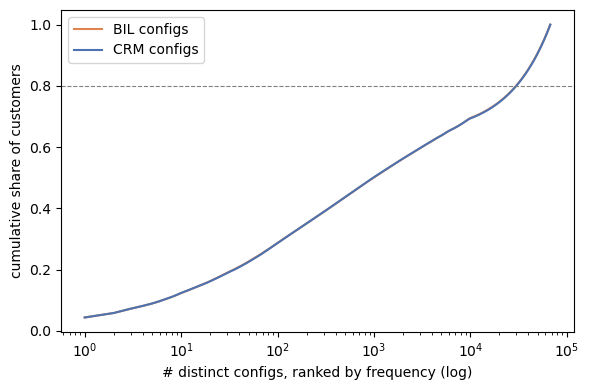

# distinct BIL configs covering 50% of customers: 990 of 67,201
# distinct BIL configs covering 80% of customers: 29,713 of 67,201
# distinct BIL configs covering 90% of customers: 48,457 of 67,201
# distinct BIL configs covering 95% of customers: 57,829 of 67,201

ANSWER (8): no small set of configurations covers the base. A "classify into a known
            bundle" framing is not supported, and 2b independently rules out lookup
            because test configurations are essentially disjoint from train.


In [38]:
bil_counts = pairs['bil'].value_counts()
crm_counts = pairs['crm'].value_counts()

bil_top = (bil_counts.head(15) / len(train)).reset_index()
bil_top.columns = ['bil_config_code', 'share']
bil_top.insert(0, 'rank', range(1, len(bil_top) + 1))
bil_top['n_active_labels'] = [int(Yc[first_y.loc[c]].sum()) for c in bil_top['bil_config_code']]
print('Top 15 most common BIL configurations:')
print(bil_top[['rank', 'share', 'n_active_labels']].to_string(index=False))
save(bil_top[['rank', 'share', 'n_active_labels']], 'bil_top_configs.csv')


def coverage_curve(counts, ax, label, color):
    cum_ = counts.sort_values(ascending=False).cumsum() / counts.sum()
    ax.plot(np.arange(1, len(cum_) + 1), cum_.values, label=label, color=color)


fig, ax = plt.subplots(figsize=(6, 4))
coverage_curve(bil_counts, ax, 'BIL configs', '#DD8452')
coverage_curve(crm_counts, ax, 'CRM configs', '#4C72B0')
ax.set_xscale('log')
ax.set_xlabel('# distinct configs, ranked by frequency (log)')
ax.set_ylabel('cumulative share of customers')
ax.axhline(0.8, color='grey', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

cum = bil_counts.sort_values(ascending=False).cumsum() / bil_counts.sum()
cov_rows = []
for f in [0.5, 0.8, 0.9, 0.95]:
    n_ = int((cum < f).sum()) + 1
    print(f'# distinct BIL configs covering {f:.0%} of customers: {n_:,} of {len(bil_counts):,}')
    cov_rows.append({'coverage': f, 'n_bil_configs_needed': n_})
print('\nANSWER (8): no small set of configurations covers the base. A "classify into a known')
print('            bundle" framing is not supported, and 2b independently rules out lookup')
print('            because test configurations are essentially disjoint from train.')
save(pd.DataFrame(cov_rows).assign(n_distinct_bil_configs=int(len(bil_counts)),
                                   n_distinct_crm_configs=int(len(crm_counts))),
     'config_coverage_summary.csv');

In [39]:
segment_cols = [c for c in crm_meta if 'SUBSCRIBER_TYPE' in c or 'BUSINESS_LINE' in c]
seg = train[segment_cols].copy()
seg['n_bil_packs'] = bil_count.to_numpy()
seg['n_crm_packs'] = crm_count.to_numpy()

segment_rows = []
for c in segment_cols:
    mask = seg[c] == 1
    if mask.sum() == 0:
        continue
    avg_crm = seg.loc[mask, 'n_crm_packs'].mean()
    avg_bil = seg.loc[mask, 'n_bil_packs'].mean()
    print(f'{c:45s} n={int(mask.sum()):>7}  prevalence={mask.mean():6.2%}  '
          f'avg CRM packs={avg_crm:5.1f}  avg BIL packs={avg_bil:5.1f}')
    segment_rows.append({'segment': c, 'n_customers': int(mask.sum()),
                         'prevalence': round(float(mask.mean()), 6),
                         'avg_crm_packs': round(float(avg_crm), 3),
                         'avg_bil_packs': round(float(avg_bil), 3),
                         'near_constant_column': bool(mask.mean() > 0.99)})
print('\nADDED (8): two readings the previous version did not make --')
print('  * a segment with ~99.9% prevalence is near-constant and is NOT a useful feature,')
print('    however strongly billing complexity appears to "track" it;')
print('  * a tiny placeholder-looking category carrying roughly double the pack count of the')
print('    main population is an anomaly worth flagging, not a segment worth modelling.')
save(pd.DataFrame(segment_rows), 'segment_pack_averages.csv');

CRM_BUSINESS_LINE_ORIG_Mobile                 n= 187203  prevalence=99.87%  avg CRM packs= 12.3  avg BIL packs= 11.7
CRM_SUBSCRIBER_TYPE_ORIG_0                    n=    211  prevalence= 0.11%  avg CRM packs= 21.5  avg BIL packs= 20.5
CRM_SUBSCRIBER_TYPE_ORIG_Postpaid             n=  37797  prevalence=20.16%  avg CRM packs= 10.5  avg BIL packs= 10.0
CRM_SUBSCRIBER_TYPE_ORIG_Prepaid              n= 149662  prevalence=79.84%  avg CRM packs= 12.7  avg BIL packs= 12.1

ADDED (8): two readings the previous version did not make --
  * a segment with ~99.9% prevalence is near-constant and is NOT a useful feature,
    however strongly billing complexity appears to "track" it;
  * a tiny placeholder-looking category carrying roughly double the pack count of the
    main population is an anomaly worth flagging, not a segment worth modelling.


## 8b. Structural test: is billing additive over packs?

**ADDED (§8b).** This is the question the case study turns on, and it is answerable with
pre-processing alone. §6 shows *pairwise association*, which is confounded: a pack only ever
sold alongside the real trigger shows a high conditional probability without causing anything.

The test below is a **matched-pairs contrast**. Take two CRM configurations differing in exactly
one pack and look at how their billing configurations differ. Everything else is held fixed by
construction, so the difference is attributable to that pack.

Two things to read:

* **consistency** (`modal_share`) — does adding a given pack always produce the *same* billing
  change? Weight by evidence: packs with one or two observed pairs are noise-dominated.
* **monotonicity** (`n_bil_removed`) — does adding a pack ever *remove* a billing item? If never,
  billing is a **monotone union** over packs, a strong constraint on the Sprint 2 model class.

Caveat for the write-up: this contrast identifies the *incremental* contribution of a pack, not
its total contribution, and only some packs have a distance-1 neighbour at all. It is good
evidence about the **form** of the mapping and a poor basis for building the mapping itself.
Runtime ~1–2 minutes.

In [40]:
cnt_sorted = (pairs.groupby(['crm', 'bil']).size().rename('c').reset_index()
              .sort_values(['crm', 'c'], ascending=[True, False]).drop_duplicates('crm'))
cfg_ids = cnt_sorted['crm'].to_numpy()

Xu = Xc[first_x.loc[cfg_ids].to_numpy()]
Yu = Yc[first_y.loc[cnt_sorted['bil'].to_numpy()].to_numpy()]
print(f'{len(Xu):,} distinct CRM configurations, each with its modal billing configuration')

setsX = [frozenset(np.flatnonzero(r).tolist()) for r in Xu]
setsY = [frozenset(np.flatnonzero(r).tolist()) for r in Yu]
index = {s: i for i, s in enumerate(setsX)}

deltas = defaultdict(list)
for i, s in enumerate(setsX):
    for j in s:
        i2 = index.get(s - {j})
        if i2 is not None:
            deltas[j].append((setsY[i] - setsY[i2], setsY[i2] - setsY[i]))

n_pairs = sum(len(v) for v in deltas.values())
print(f'CRM columns with >=1 distance-1 pair: {len(deltas)} / {len(crm_cols)}')
print(f'total distance-1 configuration pairs: {n_pairs:,}')

67,434 distinct CRM configurations, each with its modal billing configuration
CRM columns with >=1 distance-1 pair: 538 / 745
total distance-1 configuration pairs: 20,997


In [41]:
rows_ = []
for j, v in deltas.items():
    c = Counter(v)
    top_delta, top_n = c.most_common(1)[0]
    rows_.append({'crm_column': crm_cols[j], 'n_pairs': len(v), 'n_distinct_deltas': len(c),
                  'modal_share': round(top_n / len(v), 6),
                  'n_bil_added': len(top_delta[0]), 'n_bil_removed': len(top_delta[1]),
                  'modal_delta_added': ';'.join(sorted(bil_cols[i] for i in top_delta[0])),
                  'modal_delta_removed': ';'.join(sorted(bil_cols[i] for i in top_delta[1]))})
D_ = pd.DataFrame(rows_).sort_values('n_pairs', ascending=False)

print('consistency of the billing delta across distance-1 pairs:')
print(D_['modal_share'].describe().round(3).to_dict())
cons_rows = []
for t in [1.0, 0.99, 0.95, 0.90]:
    m_ = D_['modal_share'] >= t
    print(f'  columns with modal_share >= {t:.2f}: {int(m_.sum()):>4}/{len(D_)}  '
          f'(covering {int(D_.loc[m_, "n_pairs"].sum()):,} of {n_pairs:,} pairs)')
    cons_rows.append({'modal_share_threshold': t, 'n_columns': int(m_.sum()),
                      'n_columns_total': len(D_),
                      'pairs_covered': int(D_.loc[m_, 'n_pairs'].sum()),
                      'pairs_total': int(n_pairs)})

n_monotone = int((D_['n_bil_removed'] == 0).sum())
print('\nmonotonicity — does adding a pack ever REMOVE a billing item?')
print(f'  columns whose modal delta removes nothing: {n_monotone}/{len(D_)}')
print(f'  n_bil_added for the modal delta, quantiles (0,.25,.5,.75,1): '
      f'{np.round(np.quantile(D_["n_bil_added"], [0, .25, .5, .75, 1]), 2)}')
display(D_.head(20))

save(D_, 'additivity_by_pack.csv')
save(pd.DataFrame(cons_rows).assign(
    n_columns_with_distance1_pair=len(deltas),
    n_distance1_pairs=int(n_pairs),
    median_modal_share=round(float(D_['modal_share'].median()), 6),
    n_columns_modal_delta_removes_nothing=n_monotone,
    median_n_bil_added=float(np.median(D_['n_bil_added'])),
), 'additivity_summary.csv');

consistency of the billing delta across distance-1 pairs:
{'count': 538.0, 'mean': 0.864, 'std': 0.213, 'min': 0.25, '25%': 0.753, '50%': 0.997, '75%': 1.0, 'max': 1.0}
  columns with modal_share >= 1.00:  268/538  (covering 1,220 of 20,997 pairs)
  columns with modal_share >= 0.99:  279/538  (covering 4,230 of 20,997 pairs)
  columns with modal_share >= 0.95:  352/538  (covering 18,805 of 20,997 pairs)
  columns with modal_share >= 0.90:  382/538  (covering 20,235 of 20,997 pairs)

monotonicity — does adding a pack ever REMOVE a billing item?
  columns whose modal delta removes nothing: 511/538
  n_bil_added for the modal delta, quantiles (0,.25,.5,.75,1): [ 0.  1.  1.  2. 10.]


,crm_column,n_pairs,n_distinct_deltas,modal_share,n_bil_added,n_bil_removed,modal_delta_added,modal_delta_removed
5,CRM_1575_PACK,1462,22,0.980164,1,0,BIL_3771_PACK,
24,CRM_1527_PACK,1293,18,0.976025,1,0,BIL_3929_PACK,
12,CRM_1594_PACK,724,8,0.987569,1,0,BIL_4036_PACK,
2,CRM_1553_PACK,684,10,0.966374,1,0,BIL_3762_PACK,
70,CRM_1547_PACK,671,11,0.980626,1,0,BIL_3943_PACK,
0,CRM_1606_PACK,535,5,0.990654,1,0,BIL_3942_PACK,
40,CRM_2089_PACK,521,10,0.975048,1,0,BIL_3740_PACK,
8,CRM_1557_PACK,447,5,0.991051,1,0,BIL_4025_PACK,
179,CRM_1552_PACK,419,2,0.997613,1,0,BIL_4102_PACK,
53,CRM_2079_PACK,379,5,0.986807,1,0,BIL_3737_PACK,


## 9. Summary of EDA findings for Sprint 2

**REWRITTEN (§9).** The previous summary carried three statements the outputs do not support —
a recommendation to stratify the validation split by customer segment, an unresolved conditional
about the long tail, and "business line is a cheap, strong feature" for a column active in 99.9%
of rows. Each is corrected below, and the findings the notebook measured but never stated are
added.

### Data quality and integrity
* **Referential integrity holds** (§2b): train/test CRM columns match exactly, no nulls, no
  non-binary values, no duplicate or overlapping `MSISDN`. Distributional integrity also holds —
  CRM marginals agree closely between train and test, and no pack appears in one file and never
  in the other.
* **Two constant CRM columns** (§2) are a safe drop. Note the asymmetry: a constant *target*
  would not be droppable, since all 731 labels must be emitted for EMR.
* **A small share of rows carries two or more `SUBSCRIBER_TYPE` flags** (§4) — a genuine
  data-quality issue, visible only after fixing the grouping bug.
* **CRM and BILLING do not share a status vocabulary** (§4): the category sets differ, which is
  a candidate mechanism for §3c.

### Structure of the mapping
* **Billing is close to a monotone union over packs** (§8b): adding a CRM pack adds a consistent
  set of billing items and essentially never removes one. This is the strongest structural result
  available at pre-processing time and it constrains the Sprint 2 model class.
* **No column-level bijection, but strong one-to-one channels** (§6, §6b): several bundled CRM
  packs each drive a *different* billing item at ~0.99 confidence in both directions. Bundled is
  not interchangeable.
* **Many-to-one is rare** (§3): only a small share of billing configurations are fed by more than
  one CRM configuration. The brief emphasises it more than the data supports.
* **The pack counts are near-preserved** (§5, §7d): `#CRM ≈ #BIL` per customer, with the loss
  concentrated in specific segments.

### Noise, and what to do about it
* **The EMR ceiling of an exact-match lookup is computed, not asserted** (§3), along with a
  per-row provisioning error rate — with the caveat that errors inside singleton configurations
  are undetectable, so it is a lower bound.
* **The cleaning rule follows from §3c, not from preference.** If the within-configuration
  variation is scattered and non-repeating, majority-vote the repeated configurations, drop the
  exact 50/50 groups (no evidence either way) and leave singletons untouched. If it is
  concentrated in a few recurring columns, those are an unmodelled covariate and must **not** be
  majority-voted away — the minority variant is correct for its customer.
* **Report rows actually changed**, not rows in touched groups; the two differ by more than an
  order of magnitude.

### Consequences for Sprint 2
* **Group the train/validation split on the CRM configuration code** (§3b). 63.6% of rows are
  exact duplicates; a random row split would report roughly the lookup ceiling instead of
  generalisation. Stratifying by segment does not fix this. Effective sample size is the number
  of distinct configurations, and row-wise standard errors are too narrow by the square root of
  the ratio.
* **Test configurations are essentially disjoint from train** (§2b) while every test row is built
  from packs seen in training. The task is **compositional generalisation** — known primitives,
  unseen combinations — which rules out memorisation-style approaches (lookup, nearest-neighbour
  on whole configurations, powerset classification) and favours an additive/compositional model.
* **No small set of configurations covers the base** (§8): the "classify into a known bundle"
  framing is not supported.
* **The rare-label tail is the EMR bottleneck** (§5c): the reportable number is the share of
  *rows* holding at least one rare positive, which bounds any model predicting the tail as zero.
* **Pack-count outliers are flagged, never removed** (§5b), and the bands carry a measured
  difference in ambiguity and configuration diversity — a population to monitor, not to delete.
* **Do not deduplicate targets** (§6b). Only exactly-identical columns are safe to collapse, and
  then only on the feature side; near-duplicates at 0.99 still disagree on enough rows to cap EMR
  well below what the model could otherwise reach.
* **Linear dimensionality reduction is inappropriate** (§7a): variance in sparse binary data is
  dominated by a handful of dense columns, and uncentred SVD components track pack count. The
  appropriate decomposition is Boolean, which §8b points at directly.


## 9b. Bridge to the cleaning section

Section 10 was written against `crm_key` / `bil_key` — the 745- and 731-character bitstrings
produced by `train[cols].astype(str).agg(''.join, axis=1)`. The EDA above uses integer
configuration codes instead, so those two names are recreated here.

They are built from the packed bits rather than by joining strings: `A + 48` maps 0 -> '0'
and 1 -> '1' in ASCII, so `tobytes().decode()` yields exactly the same string the old cell
produced, in seconds instead of minutes. The asserts prove the two encodings agree.


In [42]:
def bitstring_keys(A):
    """Identical output to astype(str).agg(''.join, axis=1), ~100x faster."""
    return pd.Series([r.tobytes().decode('ascii') for r in (A.astype(np.uint8) + 48)])

crm_key = bitstring_keys(Xc)
bil_key = bitstring_keys(Yc)

assert crm_key.nunique() == n_crm_cfg, 'bitstring keys disagree with packbits codes (CRM)'
assert bil_key.nunique() == n_bil_cfg, 'bitstring keys disagree with packbits codes (BIL)'
print(f'crm_key / bil_key rebuilt: {crm_key.nunique():,} / {bil_key.nunique():,} distinct')


crm_key / bil_key rebuilt: 67,434 / 67,201 distinct


## 10. Cleaning & export

Turning the EDA above into an actual cleaned, modeling-ready dataset. Three concrete
changes, in order of confidence:

1. **Drop the 2 constant CRM columns** found in §2 — zero information.
2. **Collapse near-duplicate pack columns** (§6 found ~0.95+ correlated pairs) down to one
   representative each, *within* CRM and *within* BIL separately — never across the two,
   since collapsing a CRM column into a BIL column would just be modeling the answer.
3. **Majority-vote relabel the ambiguous CRM groups** (§3): for each CRM config that maps to
   more than one BIL config, replace its rows' BIL labels with the group's majority BIL
   config — but only where that majority is confident (share >= 0.65), leaving small,
   genuinely coin-flip-looking groups untouched rather than force-labeling them.

Why threshold at 0.65: checking the 617 ambiguous groups directly shows the pattern is not
uniform. The largest groups (up to 8,114 rows) have a 98.7-99.9% majority — clean landslides.
Across all 617 groups the average majority share is only 80%, but that's dragged down by
small groups (2-5 rows) where a single mislabeled row swings the ratio dramatically — those
are also the groups that barely move total EMR either way. Relabeling only confident
majorities targets the noise where it's both correctable and impactful, and leaves alone the
groups where "majority vote" would just be picking a winner from a coin flip.

In [43]:
from src.preprocessing import (
    sparse_binary_corr_matrix,
    correlation_clusters,
    cluster_columns_to_drop,
    compute_majority_labels,
    relabel_ambiguous_rows,
    hamming_distance_report,
)


### 10.1 Drop constant CRM columns

In [44]:
crm_cols_clean = [c for c in crm_cols if c not in constant_crm]
print(f'Dropped {len(constant_crm)} constant CRM columns: {constant_crm}')
print(f'CRM columns remaining: {len(crm_cols_clean)} / {len(crm_cols)}')


Dropped 2 constant CRM columns: ['CRM_2396_PACK', 'CRM_2398_PACK']
CRM columns remaining: 743 / 745


> **Note carried over from 6b — read before running 10.2.**
>
> 6b measured two things that bear directly on this step. First, the only group of
> *exactly* identical columns anywhere is `['CRM_2396_PACK', 'CRM_2398_PACK']`, and those
> are the two all-zero constant columns — so there are **no genuine exact duplicates** to
> collapse. Second, 9 of the 10 most-correlated CRM pairs drive a **different** billing
> pack each: bundled together is not the same as interchangeable.
>
> On the target side the collapsed pairs disagree on 0.21%-2.94% of rows, so reconstructing
> the 8 dropped BIL columns from their cluster representative caps EMR at roughly **0.90**
> before any model is fitted. All 731 targets have to be emitted for the metric.
>
> Left as-is pending a decision; `near_duplicate_crm_pairs.csv` and
> `near_duplicate_bil_pairs.csv` hold the evidence.


### 10.2 Collapse near-duplicate pack columns

Recomputed on the *full* training data (not the 30k-row EDA sample from §6) since this
decides which columns actually get dropped. Uses `sparse_binary_corr_matrix` (§0) rather than
a dense mean-centered Pearson matrix: for Bernoulli columns, `corr(X,Y)` reduces to
`(E[XY] - E[X]E[Y]) / sqrt(Var(X)Var(Y))`, and `E[XY]` is a sparse dot product — no need to
ever materialize a dense centered ~745/731-column matrix over 187k rows. Verified numerically
identical (max abs diff ~1e-6) to the dense version on a sample before switching.

In [45]:
crm_corr_full = sparse_binary_corr_matrix(train[crm_packs], train[crm_packs])
bil_corr_full = sparse_binary_corr_matrix(train[bil_packs], train[bil_packs])

crm_clusters = correlation_clusters(crm_packs, crm_corr_full, threshold=0.95)
bil_clusters = correlation_clusters(bil_packs, bil_corr_full, threshold=0.95)

crm_drop_dupes = cluster_columns_to_drop(crm_clusters)
bil_drop_dupes = cluster_columns_to_drop(bil_clusters)

print(f'CRM: {len(crm_clusters)} redundant clusters -> dropping {len(crm_drop_dupes)} columns')
for g in crm_clusters:
    print(' ', g)
print(f'\nBIL: {len(bil_clusters)} redundant clusters -> dropping {len(bil_drop_dupes)} columns')
for g in bil_clusters:
    print(' ', g)

crm_cols_clean = [c for c in crm_cols_clean if c not in crm_drop_dupes]
bil_cols_clean = [c for c in bil_cols if c not in bil_drop_dupes]
print(f'\nCRM columns remaining: {len(crm_cols_clean)} / {len(crm_cols)}')
print(f'BIL columns remaining: {len(bil_cols_clean)} / {len(bil_cols)}')

cluster_rows = []
for system, clusters in [('CRM', crm_clusters), ('BIL', bil_clusters)]:
    for group in clusters:
        keep, *drop = sorted(group)
        cluster_rows.append({
            'system': system, 'kept_column': keep,
            'dropped_columns': ';'.join(drop), 'size': len(group),
        })
pd.DataFrame(cluster_rows).pipe(save, 'correlation_clusters.csv')


CRM: 4 redundant clusters -> dropping 9 columns
  ['CRM_1529_PACK', 'CRM_1532_PACK', 'CRM_1533_PACK', 'CRM_1541_PACK', 'CRM_1542_PACK']
  ['CRM_1536_PACK', 'CRM_1539_PACK']
  ['CRM_1549_PACK', 'CRM_1563_PACK']
  ['CRM_2076_PACK', 'CRM_2077_PACK', 'CRM_2087_PACK', 'CRM_2088_PACK']

BIL: 3 redundant clusters -> dropping 8 columns
  ['BIL_3744_PACK', 'BIL_3745_PACK', 'BIL_3749_PACK', 'BIL_3750_PACK']
  ['BIL_3921_PACK', 'BIL_3922_PACK', 'BIL_3927_PACK', 'BIL_3933_PACK', 'BIL_3934_PACK']
  ['BIL_3996_PACK', 'BIL_3997_PACK']

CRM columns remaining: 734 / 745
BIL columns remaining: 723 / 731


,system,kept_column,dropped_columns,size
0,CRM,CRM_1529_PACK,CRM_1532_PACK;CRM_1533_PACK;CRM_1541_PACK;CRM_...,5
1,CRM,CRM_1536_PACK,CRM_1539_PACK,2
2,CRM,CRM_1549_PACK,CRM_1563_PACK,2
3,CRM,CRM_2076_PACK,CRM_2077_PACK;CRM_2087_PACK;CRM_2088_PACK,4
4,BIL,BIL_3744_PACK,BIL_3745_PACK;BIL_3749_PACK;BIL_3750_PACK,4
5,BIL,BIL_3921_PACK,BIL_3922_PACK;BIL_3927_PACK;BIL_3933_PACK;BIL_...,5
6,BIL,BIL_3996_PACK,BIL_3997_PACK,2


### 10.3 Majority-vote relabel confidently-ambiguous CRM groups

In [46]:
RELABEL_THRESHOLD = 0.65

majority = compute_majority_labels(crm_key, bil_key)
train_relabeled, n_rows_relabeled, n_groups_relabeled = relabel_ambiguous_rows(
    train, bil_cols, crm_key, bil_key, majority, threshold=RELABEL_THRESHOLD
)
print(f'Relabeled {n_rows_relabeled} rows across {n_groups_relabeled} confidently-ambiguous '
      f'CRM groups (threshold={RELABEL_THRESHOLD})')

# how much ambiguity is left after relabeling?
new_bil_key = train_relabeled[bil_cols].astype(str).agg(''.join, axis=1)
remaining = pd.DataFrame({'crm': crm_key, 'bil': new_bil_key}).groupby('crm')['bil'].nunique()
n_remaining_ambiguous = (remaining > 1).sum()
print(f'Remaining ambiguous CRM groups: {n_remaining_ambiguous} (was {n_amb_cfg} before relabeling) — '
      f'these are the low-confidence, low-row-count groups left untouched on purpose')

pd.DataFrame([{
    'relabel_threshold': RELABEL_THRESHOLD,
    'n_rows_relabeled': int(n_rows_relabeled),
    'n_groups_relabeled': int(n_groups_relabeled),
    'n_ambiguous_groups_before': n_amb_cfg,   # was hardcoded 617
    'n_remaining_ambiguous_groups': int(n_remaining_ambiguous),
}]).pipe(save, 'relabel_summary.csv')

Relabeled 57656 rows across 494 confidently-ambiguous CRM groups (threshold=0.65)
Remaining ambiguous CRM groups: 123 (was 617 before relabeling) — these are the low-confidence, low-row-count groups left untouched on purpose


,relabel_threshold,n_rows_relabeled,n_groups_relabeled,n_ambiguous_groups_before,n_remaining_ambiguous_groups
0,0.65,57656,494,617,123


### 10.3b Typo audit: refining the relabel rationale with Hamming distance

The relabel above only uses *share* (how dominant a group's majority BIL config is). Hamming
distance — how many bits a row's BIL config differs from its group's majority — is an
independent, orthogonal signal: a row 1-2 bits away from the majority looks like a single
fat-fingered pack toggle (a manual-entry "typo"), while a row dozens of bits away looks like a
genuinely different, and possibly *legitimate*, provisioning outcome that a share-only rule
could otherwise steamroll. This is diagnostic — it doesn't change §10.3's relabel behavior —
but it's the statistical check that the 0.65 threshold isn't accidentally erasing real
variation.

In [47]:
hamming = hamming_distance_report(train, bil_cols, crm_key, bil_key, majority)
hamming['dist_bucket'] = pd.cut(
    hamming['hamming_dist_to_majority'],
    bins=[-1, 0, 2, np.inf],
    labels=['matches_majority(0)', 'likely_typo(1-2)', 'likely_distinct(3+)'],
)
hamming['group_was_relabeled'] = hamming['crm'].isin(
    majority.loc[(majority['n_distinct'] > 1) & (majority['share'] >= RELABEL_THRESHOLD)].index
)

typo_summary = (
    hamming.groupby(['dist_bucket', 'group_was_relabeled'], observed=True)
    .size()
    .reset_index(name='n_rows')
)
print(f'{len(hamming)} rows across all {n_amb_cfg} ambiguous CRM groups, bucketed by distance to '
      f"their group's majority BIL config:")
display(typo_summary)

typo_summary.pipe(save, 'typo_audit.csv')

# Sanity check: rows already caught by the 0.65-share relabel should skew toward
# small Hamming distance (simple errors); rows the relabel deliberately left alone
# should skew toward large distance (real variation, correctly not force-labeled).


58402 rows across all 617 ambiguous CRM groups, bucketed by distance to their group's majority BIL config:


,dist_bucket,group_was_relabeled,n_rows
0,matches_majority(0),False,395
1,matches_majority(0),True,56692
2,likely_typo(1-2),False,330
3,likely_typo(1-2),True,861
4,likely_distinct(3+),False,21
5,likely_distinct(3+),True,103


,dist_bucket,group_was_relabeled,n_rows
0,matches_majority(0),False,395
1,matches_majority(0),True,56692
2,likely_typo(1-2),False,330
3,likely_typo(1-2),True,861
4,likely_distinct(3+),False,21
5,likely_distinct(3+),True,103


### 10.4 Assemble final cleaned column sets and apply to train/test

In [48]:
train_clean = train_relabeled[['MSISDN'] + crm_cols_clean + bil_cols_clean].copy()
test_clean = test[['MSISDN'] + crm_cols_clean].copy()

print('train_clean shape:', train_clean.shape, '(was', train.shape, ')')
print('test_clean shape:', test_clean.shape, '(was', test.shape, ')')
assert list(test_clean.columns[1:]) == crm_cols_clean
assert train_clean[crm_cols_clean + bil_cols_clean].isna().sum().sum() == 0


train_clean shape: (187442, 1458) (was (187442, 1477) )
test_clean shape: (97100, 735) (was (97100, 746) )


### 10.5 Export for Sprint 2

In [49]:
train_clean.to_csv(f'{DATA_DIR}/train_clean.csv', index=False)
test_clean.to_csv(f'{DATA_DIR}/test_clean.csv', index=False)
print(f'Wrote {DATA_DIR}/train_clean.csv and {DATA_DIR}/test_clean.csv')
print('Note: re-loading these needs the same int8 dtype map as §1 (to_csv does not persist dtypes).')


Wrote ../data/train_clean.csv and ../data/test_clean.csv
Note: re-loading these needs the same int8 dtype map as §1 (to_csv does not persist dtypes).


### Export manifest

**ADDED (§9).** Generated, not maintained by hand: every file written through `save()` is listed
here. If a cell was skipped or failed, its file is simply absent — which makes a partial run
visible instead of silent.

`src/export_summaries.py` is deliberately **not** called. The previous version wrote these
summaries inline and then recomputed all of them through that module, producing two
implementations of the same numbers with last-writer-wins.

In [50]:
manifest = pd.DataFrame(EXPORTS).drop_duplicates('file', keep='last').reset_index(drop=True)
manifest.to_csv(f'{DERIVED_DIR}/_manifest.csv', index=False)
print(f'{len(manifest)} derived files written to {os.path.abspath(DERIVED_DIR)}')
display(manifest)

on_disk = {f for f in os.listdir(DERIVED_DIR) if f.endswith('.csv')}
missing = set(manifest['file']) - on_disk
extra = on_disk - set(manifest['file']) - {'_manifest.csv'}
print('files registered but missing on disk:', sorted(missing) if missing else 'none')
print('files on disk not written by this run (stale?):', sorted(extra) if extra else 'none')

42 derived files written to C:\Users\andre\ECQ\data\derived


,file,rows,cols
0,basic_sanity.csv,1,10
1,constant_columns.csv,2,2
2,referential_integrity.csv,1,8
3,train_test_marginal_shift.csv,745,7
4,train_test_drift.csv,1,9
5,bil_per_crm_config_distribution.csv,9,2
6,crm_bil_relationship_summary.csv,1,19
7,validation_design.csv,1,8
8,within_config_variation_by_column.csv,731,3
9,within_config_difference_patterns.csv,25,3


files registered but missing on disk: none
files on disk not written by this run (stale?): ['within_config_variation_summary.csv']
